In [4]:
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import prody as pr
import itertools
import bisect
from ipywidgets import interact, FloatSlider
import ipywidgets as widgets
from IPython.display import display
import numpy as np
import gudhi

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"]
})


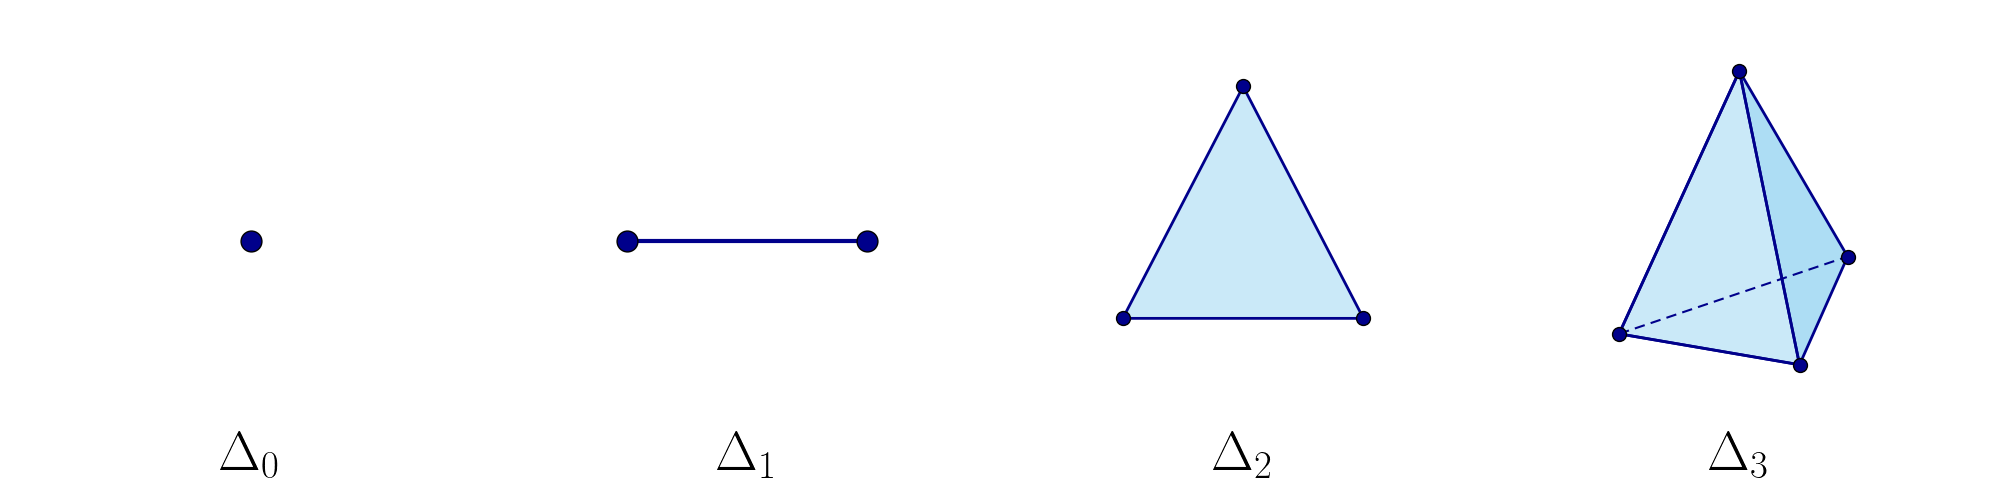

In [4]:
def plot_simplex_didatico():
    # 1 linha e 4 colunas para os sínplices de dimensão 0 a 3
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    
    # Cores personalizadas
    cor_face = (0.54, 0.81, 0.94, 0.45)
    cor_borda = 'darkblue'
    
    # --- Dimensão 0: Ponto ---
    axes[0].plot(0, 0, 'ko', markersize=15, markerfacecolor=cor_borda, markeredgecolor="black")
    axes[0].set_title(r"$\Delta_0$", y=-0.01,  fontsize=40)
    axes[0].set_xlim(-1, 1); axes[0].set_ylim(-1, 1)
    axes[0].axis('off')
    
    # --- Dimensão 1: Segmento ---
    axes[1].plot([-1, 1], [0, 0], 'ko', markerfacecolor=cor_borda, markeredgecolor="black", markersize=15, zorder=3)
    axes[1].plot([-1, 1], [0, 0], '-', color=cor_borda, lw=3, zorder=2)
    axes[1].set_title(r"$\Delta_1$", y=-0.01,  fontsize=40)
    axes[1].set_xlim(-2, 2); axes[1].set_ylim(-1, 1)
    axes[1].axis('off')
    
    # --- Dimensão 2: Triângulo Preenchido ---
    pts_2d = np.array([[0, 1], [-1, -0.5], [1, -0.5]])
    tri = patches.Polygon(pts_2d, closed=True, facecolor=cor_face, edgecolor=cor_borda, lw=2, zorder=2)
    axes[2].add_patch(tri)
    axes[2].plot(pts_2d[:,0], pts_2d[:,1], 'ko', markersize=10, markerfacecolor=cor_borda, markeredgecolor="black", zorder=3)
    axes[2].set_title(r"$\Delta_2$", y=-0.01,  fontsize=40)
    axes[2].set_xlim(-2, 2); axes[2].set_ylim(-1.5, 1.5)
    axes[2].axis('off')
    
    # --- Dimensão 3: Tetraedro (Representação 2D) ---
    # Vértices projetados para perspectiva 3D
    v = np.array([
        [0, 1.1],     # Vértice do topo
        [-1, -0.6],   # Vértice inferior esquerdo
        [0.5, -0.8],    # Vértice inferior direito
        [0.9, -0.1]   # Vértice interno/profundidade
    ])
    
    # Definição das faces translúcidas com a cor de borda correta
    face1 = patches.Polygon([v[0], v[1], v[3]], closed=True, facecolor=cor_face, edgecolor='none', lw=1, zorder=1)
    face2 = patches.Polygon([v[0], v[2], v[3]], closed=True, facecolor=cor_face, edgecolor='none', lw=1, zorder=1)
    face3 = patches.Polygon([v[1], v[2], v[3]], closed=True, facecolor=cor_face, edgecolor='none', lw=1, zorder=1)
    face4 = patches.Polygon([v[0], v[1], v[2]], closed=True, fill=False, edgecolor=cor_borda, lw=2, zorder=2) 
    
    axes[3].add_patch(face1)
    axes[3].add_patch(face2)
    axes[3].add_patch(face3)
    axes[3].add_patch(face4)
    
    # Arestas do tetraedro
    arestas_visiveis = [(0,1), (0,2), (0,3), (1,2), (2,3)] 
    arestas_ocultas  = [(1,3)] 
    
    # Desenha as arestas externas
    for edge in arestas_visiveis:
        axes[3].plot([v[edge[0], 0], v[edge[1], 0]], 
                     [v[edge[0], 1], v[edge[1], 1]], '-', color=cor_borda, lw=2, zorder=2)
        
    # Desenha as arestas internas pontilhadas usando a cor padrão (cor_borda)
    for edge in arestas_ocultas:
        axes[3].plot([v[edge[0], 0], v[edge[1], 0]], 
                     [v[edge[0], 1], v[edge[1], 1]], 
                     color=cor_borda, 
                     linestyle=(0, (5, 3)),  
                     lw=1.5, 
                     zorder=2)
        
    # Vértices por cima de tudo
    axes[3].plot(v[:, 0], v[:, 1], 'ko', markersize=10, markerfacecolor=cor_borda, markeredgecolor="black", zorder=4)
    
    # CORREÇÃO: Título alinhado perfeitamente embaixo (y=-0.01 igual aos outros)
    axes[3].set_title(r"$\Delta_3$", y=-0.01, fontsize=40)
    axes[3].set_xlim(-2, 2); axes[3].set_ylim(-1.5, 1.5)
    axes[3].axis('off')
    
    plt.tight_layout()
    plt.show()

# Executa o plot informativo
plot_simplex_didatico()

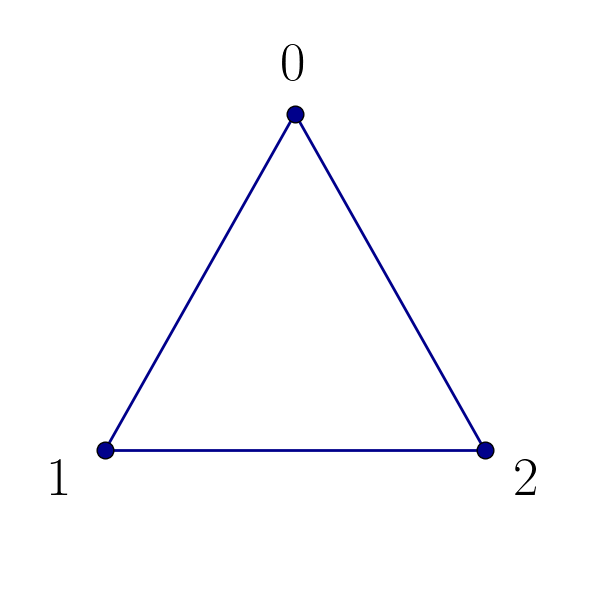

In [5]:
def plot_ex_31():
    fig, ax = plt.subplots(figsize=(6, 6))
    
    cor_borda = 'darkblue'
    # 1. Coordenadas dos 3 vértices (formato de triângulo)
    v = np.array([
        [0, 0.8],     # Vértice 0 (topo)
        [-0.8, -0.5], # Vértice 1 (inferior esquerdo)
        [0.8, -0.5]   # Vértice 2 (inferior direito)
    ])
    
    # 2. Desenhar as arestas (1-símplices) ligando os vértices
    # Conectamos: (0 a 1), (1 a 2) e (2 a 0)
    arestas = [(0, 1), (1, 2), (2, 0)]
    for edge in arestas:
        ax.plot([v[edge[0], 0], v[edge[1], 0]], 
                [v[edge[0], 1], v[edge[1], 1]], 
                color=cor_borda, linewidth=2, zorder=1)
        
    # 3. Desenhar os vértices (0-símplices) por cima das linhas
    ax.plot(v[:, 0], v[:, 1], 'ko', markersize=12, markerfacecolor=cor_borda, markeredgecolor="black", zorder=2)
    
    # 4. Enumerar os vértices (0, 1, 2) adicionando um pequeno deslocamento (offset)
    # para o texto não ficar exatamente em cima do ponto
    labels = ['0', '1', '2']
    offsets = [
        [0.0, 0.18],   # Deslocamento para cima no vértice 0
        [-0.18, -0.12], # Deslocamento para a esquerda/baixo no vértice 1
        [0.18, -0.12]   # Deslocamento para a direita/baixo no vértice 2
    ]
    
    for i in range(3):
        ax.text(v[i, 0] + offsets[i][0], 
                v[i, 1] + offsets[i][1], 
                labels[i], 
                fontsize=40, fontweight='bold', 
                ha='center', va='center')
        
    # Configurações de eixos e título didático
    # ax.set_title("Complexo Simplicial de Dimensão 1 (Não preenchido), fontsize=12, pad=15)
    ax.set_xlim(-1.2, 1.2)
    ax.set_ylim(-1.0, 1.2)
    ax.axis('off') # Remove as bordas do gráfico para foco total no elemento
    
    plt.tight_layout()
    plt.show()

plot_ex_31()

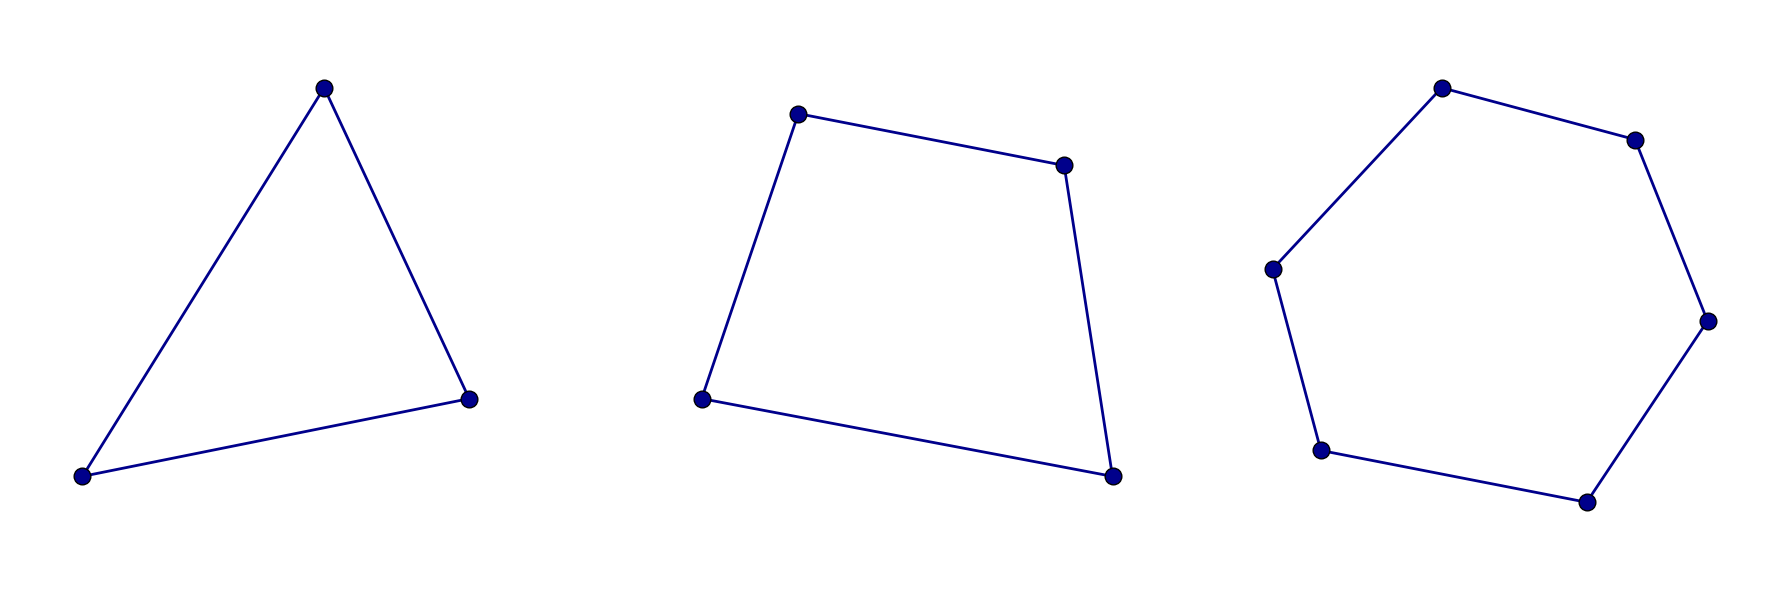

In [6]:
import matplotlib.pyplot as plt
import numpy as np

def ex_triangulos():
    # Cria uma grade com 1 linha e 3 colunas
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    cor_borda = 'darkblue'
    
    # -------------------------------------------------------------------------
    # 1. Triângulo Escaleno (Arestas com tamanhos diferentes)
    # -------------------------------------------------------------------------
    v_tri = np.array([
        [0.1, 0.9],     # Vértice superior deslocado
        [-0.9, -0.6],   # Vértice inferior esquerdo
        [0.7, -0.3]     # Vértice inferior direito assimétrico
    ])
    
    arestas_tri = [(0, 1), (1, 2), (2, 0)]
    for edge in arestas_tri:
        axes[0].plot([v_tri[edge[0], 0], v_tri[edge[1], 0]], 
                     [v_tri[edge[0], 1], v_tri[edge[1], 1]], 
                     color=cor_borda, linewidth=2, zorder=1)
        
    axes[0].plot(v_tri[:, 0], v_tri[:, 1], 'ko', markersize=12, 
                 markerfacecolor=cor_borda, markeredgecolor="black", zorder=2)
    
    axes[0].set_xlim(-1.2, 1.2); axes[0].set_ylim(-1.0, 1.2)
    axes[0].axis('off')

    # -------------------------------------------------------------------------
    # 2. Quadrilátero Irregular (Arestas inclinadas)
    # -------------------------------------------------------------------------
    v_quad = np.array([
        [-0.4, 0.8],    # Superior esquerdo
        [0.7, 0.6],     # Superior direito inclinado
        [0.9, -0.6],    # Inferior direito
        [-0.8, -0.3]    # Inferior esquerdo totalmente inclinado
    ])
    
    # Conexões fechando o quadrilátero: 0->1->2->3->0
    arestas_quad = [(0, 1), (1, 2), (2, 3), (3, 0)]
    for edge in arestas_quad:
        axes[1].plot([v_quad[edge[0], 0], v_quad[edge[1], 0]], 
                     [v_quad[edge[0], 1], v_quad[edge[1], 1]], 
                     color=cor_borda, linewidth=2, zorder=1)
        
    axes[1].plot(v_quad[:, 0], v_quad[:, 1], 'ko', markersize=12, 
                 markerfacecolor=cor_borda, markeredgecolor="black", zorder=2)
    
    axes[1].set_xlim(-1.2, 1.2); axes[1].set_ylim(-1.0, 1.2)
    axes[1].axis('off')

    # -------------------------------------------------------------------------
    # 3. Polígono de 6 Vértices / Hexágono Irregular (Tamanhos diferentes)
    # -------------------------------------------------------------------------
    v_hex = np.array([
        [-0.2, 0.9],    # Superior 1
        [0.6, 0.7],     # Superior direito 2
        [0.9, 0.0],     # Lateral direito 3
        [0.4, -0.7],    # Inferior direito 4
        [-0.7, -0.5],   # Inferior esquerdo 5
        [-0.9, 0.2]     # Lateral esquerdo 6
    ])
    
    # Conexões fechando o hexágono: 0->1->2->3->4->5->0
    arestas_hex = [(0, 1), (1, 2), (2, 3), (3, 4), (4, 5), (5, 0)]
    for edge in arestas_hex:
        axes[2].plot([v_hex[edge[0], 0], v_hex[edge[1], 0]], 
                     [v_hex[edge[0], 1], v_hex[edge[1], 1]], 
                     color=cor_borda, linewidth=2, zorder=1)
        
    axes[2].plot(v_hex[:, 0], v_hex[:, 1], 'ko', markersize=12, 
                 markerfacecolor=cor_borda, markeredgecolor="black", zorder=2)
    
    axes[2].set_xlim(-1.2, 1.2); axes[2].set_ylim(-1.0, 1.2)
    axes[2].axis('off')

    # Ajuste fino de layout para remover eixos e espaçamentos
    plt.tight_layout()
    plt.show()

ex_triangulos()

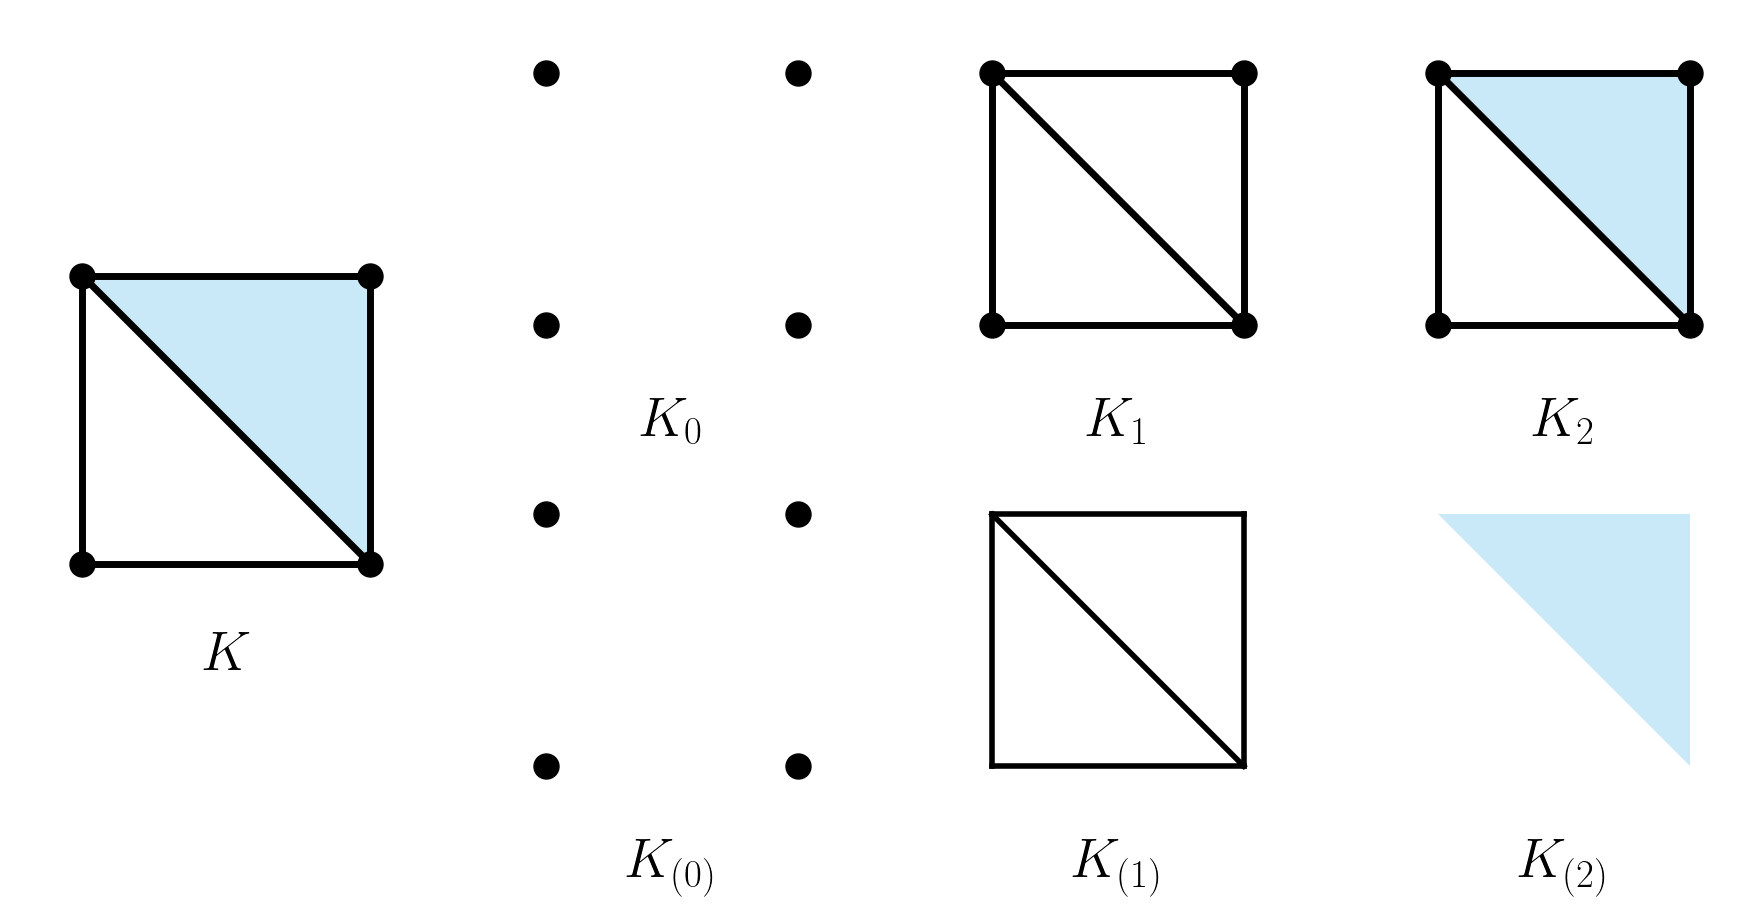

In [7]:
def plot_skeleton():
    # Cria uma figura com tamanho proporcional para o empilhamento vertical
    fig = plt.figure(figsize=(18, 9))
    
    cor_face = (0.54, 0.81, 0.94, 0.45)
    cor_borda = 'black'
    
    # Coordenadas dos 4 vértices (quadrado perfeito)
    v = np.array([
        [-0.8, 0.8],   # Vértice 0 (Superior Esquerdo)
        [0.8, 0.8],    # Vértice 1 (Superior Direito)
        [0.8, -0.8],   # Vértice 2 (Inferior Direito)
        [-0.8, -0.8]   # Vértice 3 (Inferior Esquerdo)
    ])
    
    arestas = [(0, 1), (1, 2), (2, 3), (3, 0), (0, 2)]
    pts_triangulo = [v[0], v[1], v[2]]
    
    # Lista para aplicar as configurações de limites e eixos ao final
    all_axes = []

    # -------------------------------------------------------------------------
    # COLUNA 1: O Complexo Completo K (Ocupa as duas linhas da Coluna 0)
    # -------------------------------------------------------------------------
    ax_k = plt.subplot2grid((2, 4), (0, 0), rowspan=2)
    t1 = patches.Polygon(pts_triangulo, closed=True, facecolor=cor_face, edgecolor='none', zorder=1)
    ax_k.add_patch(t1)
    for edge in arestas:
        ax_k.plot([v[edge[0], 0], v[edge[1], 0]], [v[edge[0], 1], v[edge[1], 1]], color=cor_borda, linewidth=5, zorder=2)
    ax_k.plot(v[:, 0], v[:, 1], 'ko', markersize=18, markerfacecolor=cor_borda, markeredgecolor="black", zorder=3, lw=6)
    ax_k.set_title(r"$K$", y=-0.1, fontsize=40, fontweight='bold')
    all_axes.append(ax_k)

    # -------------------------------------------------------------------------
    # COLUNA 2: Dimensão 0 (Uma em cima da outra)
    # -------------------------------------------------------------------------
    # Linha 0, Coluna 1 -> K_0 (Pontos estruturais)
    ax_k0 = plt.subplot2grid((2, 4), (0, 1))
    ax_k0.plot(v[:, 0], v[:, 1], 'ko', markersize=18, markerfacecolor=cor_borda, markeredgecolor="black", zorder=3, lw=5)
    ax_k0.set_title(r"$K_0$", y=-0.15, fontsize=40, fontweight='bold')
    all_axes.append(ax_k0)
    
    # Linha 1, Coluna 1 -> K_{(0)} (Símplices puros de dim 0)
    ax_k0_puro = plt.subplot2grid((2, 4), (1, 1))
    ax_k0_puro.plot(v[:, 0], v[:, 1], 'ko', markersize=18, markerfacecolor=cor_borda, markeredgecolor="black", zorder=3)
    ax_k0_puro.set_title(r"$K_{(0)}$", y=-0.15, fontsize=40, fontweight='bold')
    all_axes.append(ax_k0_puro)

    # -------------------------------------------------------------------------
    # COLUNA 3: Dimensão 1 (Uma em cima da outra)
    # -------------------------------------------------------------------------
    # Linha 0, Coluna 2 -> K_1 (Vértices + Arestas)
    ax_k1 = plt.subplot2grid((2, 4), (0, 2))
    for edge in arestas:
        ax_k1.plot([v[edge[0], 0], v[edge[1], 0]], [v[edge[0], 1], v[edge[1], 1]], color=cor_borda, linewidth=5, zorder=2)
    ax_k1.plot(v[:, 0], v[:, 1], 'ko', markersize=18, markerfacecolor=cor_borda, markeredgecolor="black", zorder=3, lw=10)
    ax_k1.set_title(r"$K_1$", y=-0.15, fontsize=40, fontweight='bold')
    all_axes.append(ax_k1)
    
    # Linha 1, Coluna 2 -> K_{(1)} (Símplices puros de dim 1 - Só arestas)
    ax_k1_puro = plt.subplot2grid((2, 4), (1, 2))
    for edge in arestas:
        ax_k1_puro.plot([v[edge[0], 0], v[edge[1], 0]], [v[edge[0], 1], v[edge[1], 1]], color=cor_borda, linewidth=4, zorder=2)
    ax_k1_puro.set_title(r"$K_{(1)}$", y=-0.15, fontsize=40, fontweight='bold')
    all_axes.append(ax_k1_puro)

    # -------------------------------------------------------------------------
    # COLUNA 4: Dimensão 2 (Uma em cima da outra)
    # -------------------------------------------------------------------------
    # Linha 0, Coluna 3 -> K_2 (Igual ao K original)
    ax_k2 = plt.subplot2grid((2, 4), (0, 3))
    t2 = patches.Polygon(pts_triangulo, closed=True, facecolor=cor_face, edgecolor='none', zorder=1)
    ax_k2.add_patch(t2)
    for edge in arestas:
        ax_k2.plot([v[edge[0], 0], v[edge[1], 0]], [v[edge[0], 1], v[edge[1], 1]], color=cor_borda, linewidth=5, zorder=2)
    ax_k2.plot(v[:, 0], v[:, 1], 'ko', markersize=18, markerfacecolor=cor_borda, markeredgecolor="black", zorder=3, lw=8)
    ax_k2.set_title(r"$K_2$", y=-0.15, fontsize=40, fontweight='bold')
    all_axes.append(ax_k2)
    
    # Linha 1, Coluna 3 -> K_{(2)} (Símplices puros de dim 2 - Só o triângulo)
    ax_k2_puro = plt.subplot2grid((2, 4), (1, 3))
    t3 = patches.Polygon(pts_triangulo, closed=True, facecolor=cor_face, edgecolor='none', zorder=1)
    ax_k2_puro.add_patch(t3)
    ax_k2_puro.set_title(r"$K_{(2)}$", y=-0.15, fontsize=40, fontweight='bold')
    all_axes.append(ax_k2_puro)

    # -------------------------------------------------------------------------
    # Padronização de Limites, Proporção e Remoção de Bordas
    # -------------------------------------------------------------------------
    for ax in all_axes:
        ax.set_xlim(-1.2, 1.2)
        ax.set_ylim(-1.2, 1.2)
        ax.set_aspect('equal') # Mantém o quadrado perfeito, sem distorcer as colunas
        ax.axis('off')
    
    # Ajusta o espaçamento para não cortar as letras das fórmulas matemáticas embaixo
    plt.tight_layout(h_pad=2.0, w_pad=1.0)
    plt.show()

# Executa o plot estruturado em matriz
plot_skeleton()

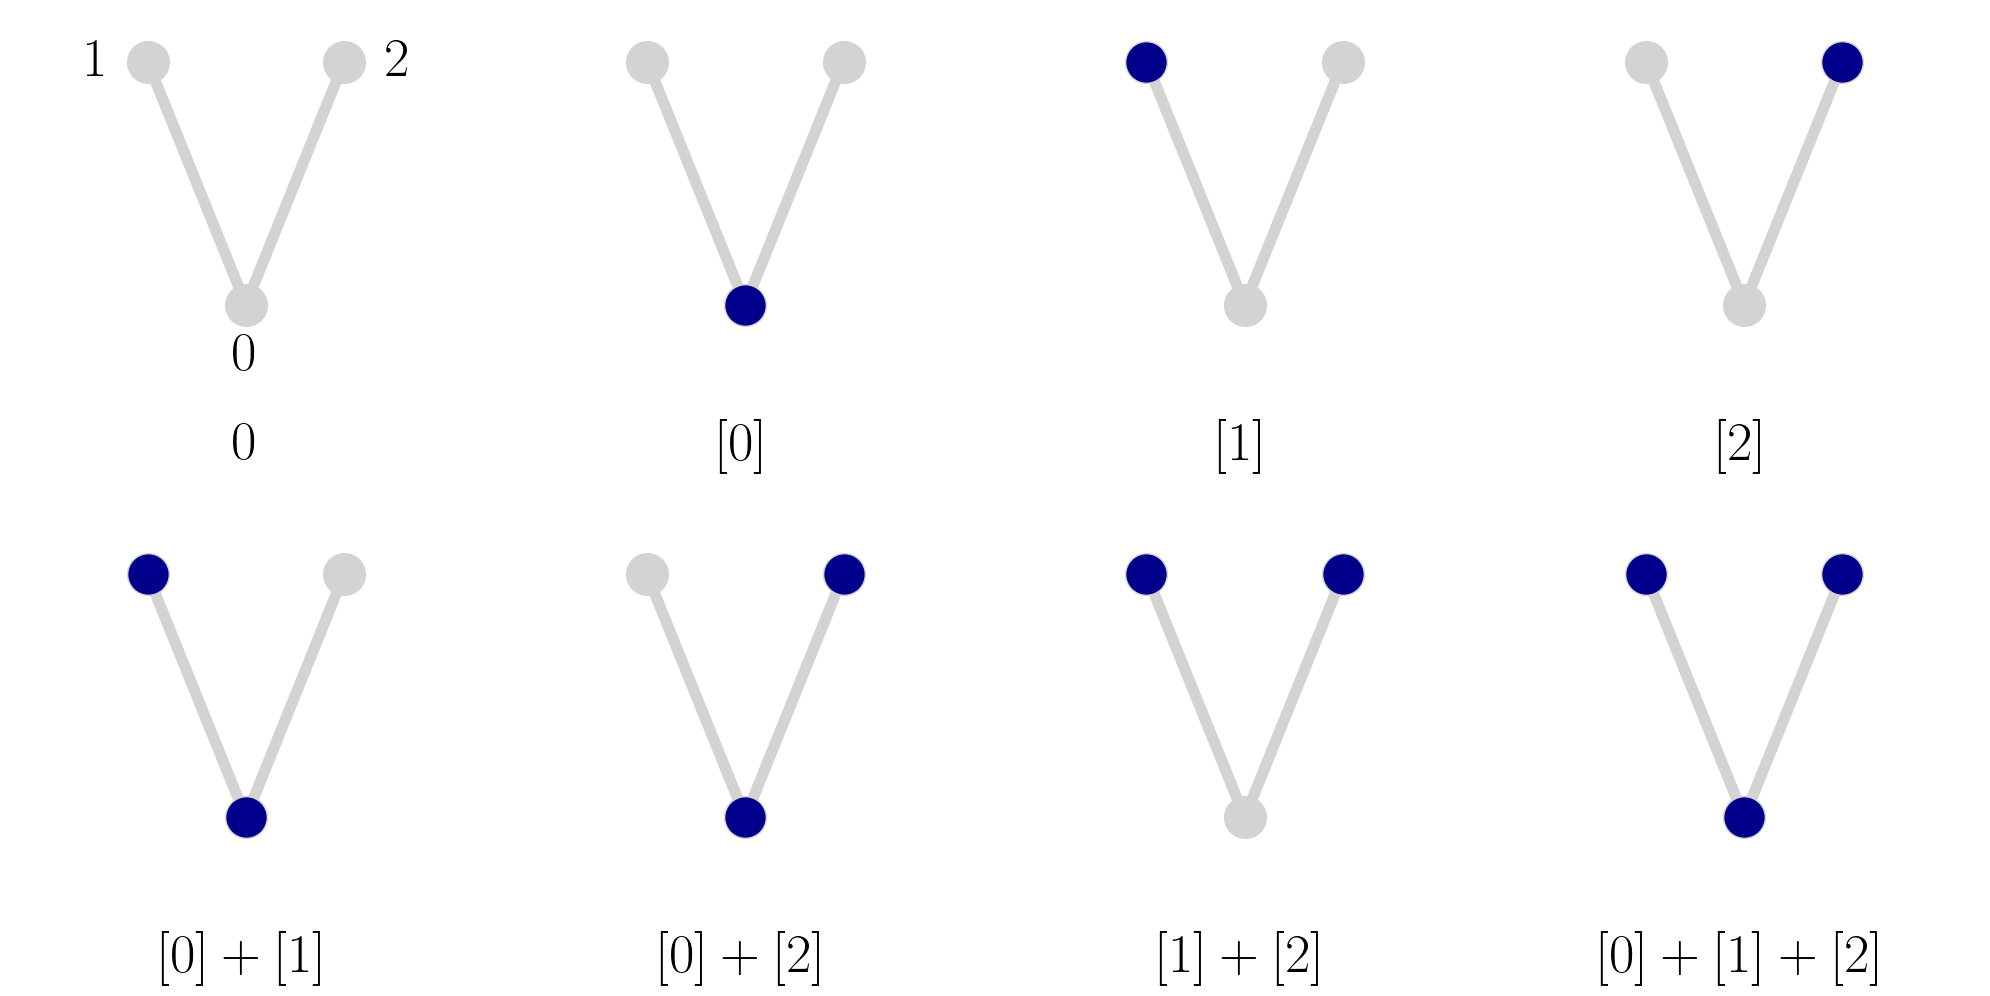

In [8]:
def plot_fases_simplexo():
    # Cria uma grade com 2 linhas e 4 colunas (8 subplots no total)
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes = axes.flatten() # Achata a matriz para um vetor de 0 a 7
    
    # Cores solicitadas
    cor_ativa = "darkblue"
    cor_borda_ativa = 'darkblue'
    cor_apagada = "lightgray"
    cor_borda_apagada = 'lightgray'
    cor_aresta_fundo = 'lightgray'
    
    # 1. Coordenadas dos 3 vértices dispostos em formato de V
    v = np.array([
        [0.0, -0.6],    # Vértice 0 (Embaixo)
        [-0.5, 0.8],    # Vértice 1 (Ponta Superior Esquerda)
        [0.5, 0.8]      # Vértice 2 (Ponta Superior Direita)
    ])
    
    # Definição dos eixos que formam o V estrutural (0->1 e 0->2)
    arestas_fundo = [(0, 1), (0, 2)]
    
    # Títulos correspondentes a cada uma das 8 fases
    titulos = [
        "0", r"$[0]$", r"$[1]$", r"$[2]$",
        r"$[0] + [1]$", r"$[0] + [2]$", r"$[1] + [2]$", r"$[0] + [1] + [2]$"
    ]
    
    # Estados de ativação dos vértices para cada fase (True = Ativo, False = Apagado)
    # Na Fase 1 (índice 0), todos os vértices começam apagados
    estados_vertices = [
        [False, False, False], # Fase 1
        [True, False, False],  # Fase 2: vértice 0 ligado
        [False, True, False],  # Fase 3: vértice 1 ligado
        [False, False, True],  # Fase 4: vértice 2 ligado
        [True, True, False],   # Fase 5: 0 e 1 ligados
        [True, False, True],   # Fase 6: 0 e 2 ligados
        [False, True, True],   # Fase 7: 1 e 2 ligados
        [True, True, True]     # Fase 8: todos ligados
    ]
    
    # Loop para construir as 8 fases consecutivas
    for fase in range(8):
        ax = axes[fase]
        
        # A) Desenhar as arestas em cinza (apagadas em segundo plano)
        for edge in arestas_fundo:
            ax.plot([v[edge[0], 0], v[edge[1], 0]], 
                    [v[edge[0], 1], v[edge[1], 1]], 
                    color=cor_aresta_fundo, linewidth=8, linestyle='-', zorder=1)
            
        # B) Desenhar e pintar cada um dos 3 vértices conforme a regra da fase
        for i in range(3):
            esta_ativo = estados_vertices[fase][i]
            
            c_face = cor_ativa if esta_ativo else cor_apagada
            m_size = 30
            
            ax.plot(v[i, 0], v[i, 1], 'o', markersize=m_size, 
                    markerfacecolor=c_face, markeredgecolor=cor_borda_apagada, zorder=2)
            
        # C) Regra Exclusiva para a Fase 1: Enumerar os vértices desativados
        if fase == 0:
            # Vértice 0 (Embaixo)
            ax.text(v[0, 0], v[0, 1] - 0.30, '0', fontsize=40, fontweight='bold', ha='center', va='center')
            # Vértice 1 (Superior Esquerda)
            ax.text(v[1, 0] - 0.25, v[1, 1], '1', fontsize=40, fontweight='bold', ha='center', va='center')
            # Vértice 2 (Superior Direita)
            ax.text(v[2, 0] + 0.28, v[2, 1], '2', fontsize=40, fontweight='bold', ha='center', va='center')

        # Configurações do layout do gráfico e inserção do título na parte inferior
        ax.set_xlim(-1.2, 1.2)
        ax.set_ylim(-1.1, 1.1)
        ax.axis('off')
        ax.set_title(titulos[fase], y=-0.2, fontsize=40, fontweight='bold')
        
    plt.tight_layout(h_pad=4.0, w_pad=2.0)
    plt.show()

# Executa o painel com as 8 fases
plot_fases_simplexo()

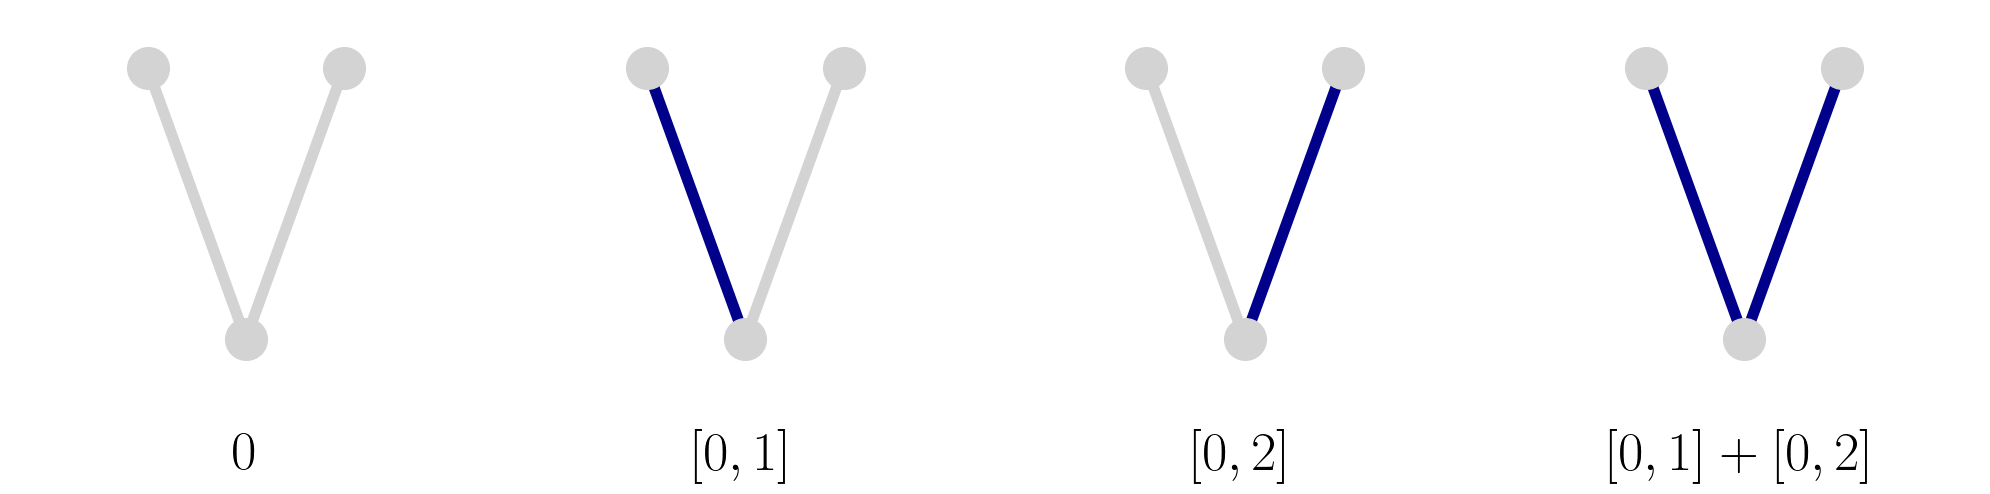

In [9]:
def plot_fases_simplexo_1():
    # Cria uma grade com 2 linhas e 4 colunas (8 subplots no total)
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    axes = axes.flatten() # Achata a matriz para um vetor de 0 a 7
    
    # Cores solicitadas
    cor_ativa = "darkblue"
    cor_borda_ativa = 'darkblue'
    cor_apagada = "lightgray"
    cor_borda_apagada = 'lightgray'
    cor_aresta_fundo = 'lightgray'
    
    # 1. Coordenadas dos 3 vértices dispostos em formato de V
    v = np.array([
        [0.0, -0.6],    # Vértice 0 (Embaixo)
        [-0.5, 0.8],    # Vértice 1 (Ponta Superior Esquerda)
        [0.5, 0.8]      # Vértice 2 (Ponta Superior Direita)
    ])
    
    # Definição dos eixos que formam o V estrutural (0->1 e 0->2)
    arestas = [(0, 1), (0, 2)]
    
    # Títulos correspondentes a cada uma das 8 fases
    titulos = [
        "0", r"$[0, 1]$", r"$[0, 2]$",
        r"$[0, 1] + [0, 2]$"
    ]
    
    # Estados de ativação dos vértices para cada fase (True = Ativo, False = Apagado)
    # Na Fase 1 (índice 0), todos os vértices começam apagados
    estados_vertices = [
        [False, False],
        [True, False],
        [False, True],
        [True, True]
    ]
    
    # Loop para construir as 8 fases consecutivas
    for fase in range(4):
        ax = axes[fase]
        
        # A) Desenhar as arestas em cinza (apagadas em segundo plano)
        for i,edge in enumerate(arestas):
            esta_ativo = estados_vertices[fase][i]
            c_aresta = cor_borda_ativa if esta_ativo else cor_borda_apagada
            ax.plot([v[edge[0], 0], v[edge[1], 0]], 
                    [v[edge[0], 1], v[edge[1], 1]], 
                    color=c_aresta, linewidth=8, linestyle='-', zorder=1)
            
        # B) Desenhar e pintar cada um dos 3 vértices conforme a regra da fase
        for i in range(3):
            m_size = 30
            
            ax.plot(v[i, 0], v[i, 1], 'o', markersize=m_size, 
                    markerfacecolor=cor_apagada, markeredgecolor=cor_borda_apagada, zorder=2)
            

        # Configurações do layout do gráfico e inserção do título na parte inferior
        ax.set_xlim(-1.2, 1.2)
        ax.set_ylim(-1.1, 1.1)
        ax.axis('off')
        ax.set_title(titulos[fase], y=-0.1, fontsize=40, fontweight='bold')
        
    plt.tight_layout(h_pad=4.0, w_pad=2.0)
    plt.show()

plot_fases_simplexo_1()

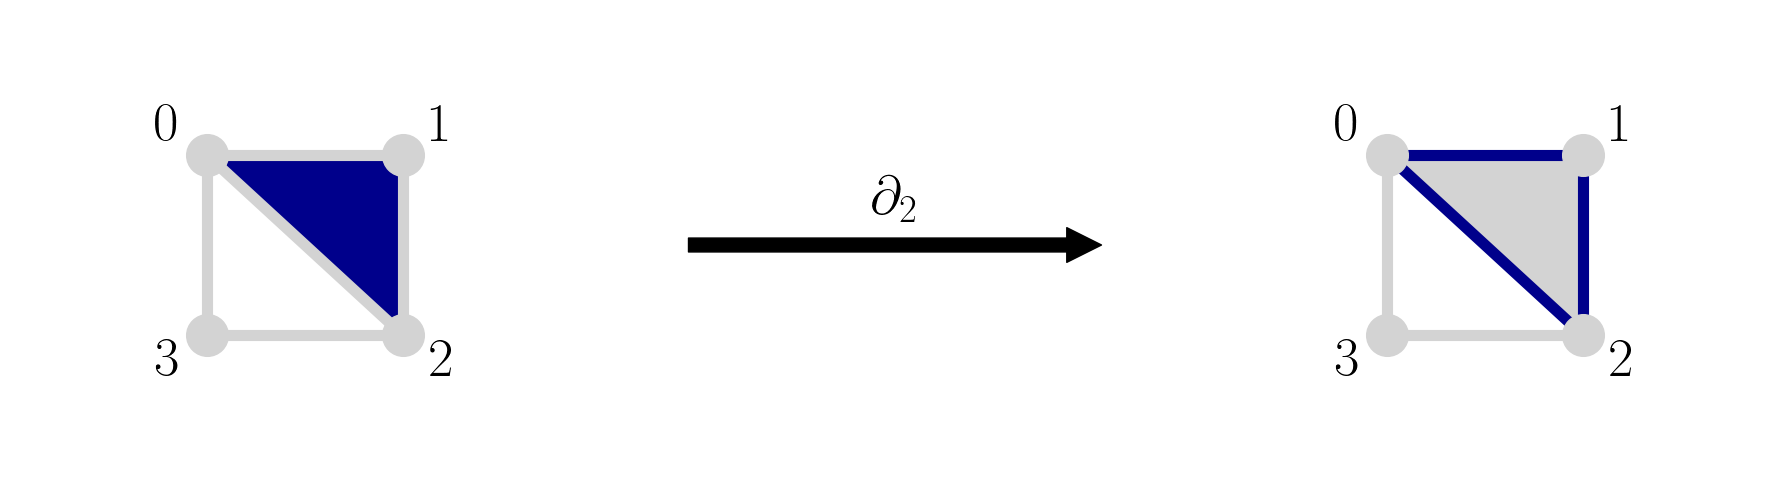

In [12]:
def plot_operador_fronteira():
    # Cria uma figura com tamanho proporcional para o empilhamento horizontal
    # (18 polegadas de largura, 8 de altura)
    fig, ax = plt.subplots(figsize=(18, 5))
    
    # Parâmetros Estéticos Solicitados
    cor_face = 'lightgray' # Vermelho translúcido (Isidoro)
    cor_borda_grau = 'lightgray'           # Cor cinza para arestas e vértices
    tamanho_fonte = 40                 # Fonte tam 40
    grosso_linha = 8                   # Linewidth 8
    grosso_vertice = 30                # Markersize 30
    
    # Coordenadas base do quadrado (centrado no eixo Y, mas deslocado no X)
    # Formato: Superior Esquerdo, Superior Direito, Inferior Direito, Inferior Esquerdo
    v_base = np.array([
        [-0.5, 0.5],   # Vértice 0
        [0.5, 0.5],    # Vértice 1
        [0.5, -0.5],   # Vértice 2
        [-0.5, -0.5]   # Vértice 3
    ])
    
    # Arestas do contorno e diagonal principal (0-1-2-3-0 + 0-2)
    arestas = [(0, 1), (1, 2), (2, 3), (3, 0), (0, 2)]
    # Pontos do triângulo diagonal superior a ser preenchido

    # ==========================================================
    # DESENHO 1: Quadrado da ESQUERDA
    # ==========================================================
    # Coordenadas deslocadas para a esquerda (X - 3.0)
    v1 = v_base - [3.0, 0]
    pts_tri1 = [v1[0], v1[1], v1[2]]
    
    # 1.1 Preencher triângulo diagonal superior
    t1 = patches.Polygon(pts_tri1, closed=True, facecolor="darkblue", edgecolor='none', zorder=1)
    ax.add_patch(t1)
    
    # 1.2 Desenhar arestas (sólidas, cinzas, grossas)
    for edge in arestas:
        # if edge == (0,1) or edge == (0,2) or edge == (1,2):
        #     ax.plot([v1[edge[0], 0], v1[edge[1], 0]], [v1[edge[0], 1], v1[edge[1], 1]], 
        #         color="darkblue", linewidth=grosso_linha, zorder=2)
        # else:
        #     ax.plot([v1[edge[0], 0], v1[edge[1], 0]], [v1[edge[0], 1], v1[edge[1], 1]], 
        #         color=cor_borda_grau, linewidth=grosso_linha, zorder=2)
        ax.plot([v1[edge[0], 0], v1[edge[1], 0]], [v1[edge[0], 1], v1[edge[1], 1]], 
                color=cor_borda_grau, linewidth=grosso_linha, zorder=2)
        
    # 1.3 Desenhar vértices (cinzas, grandes)
    ax.plot(v1[:, 0], v1[:, 1], 'o', markersize=grosso_vertice, 
            markerfacecolor=cor_borda_grau, markeredgecolor="lightgray", zorder=3)
    
    # 1.4 Enumerar vértices (fonte 40, com offset)
    # Offset para a fonte tam 40 deve ser considerável
    offsets1 = [[-0.2, 0.15], [0.2, 0.15], [0.2, -0.15], [-0.2, -0.15]]
    labels = ['0', '1', '2', '3']
    for i in range(4):
        ax.text(v1[i, 0] + offsets1[i][0], v1[i, 1] + offsets1[i][1], labels[i], 
                fontsize=tamanho_fonte, fontweight='bold', ha='center', va='center')

    # ==========================================================
    # DESENHO 2: Seta Grande e Expressão Matemática
    # ==========================================================
    # Define a posição e tamanho da seta
    # arrowstyle='-|>' define a ponta cheia
    ax.annotate("", 
                xy=(1.5, 0),    # Fim da seta (perto do quadrado direito)
                xytext=(-1.5, 0), # Início da seta (perto do quadrado esquerdo)
                arrowprops=dict(facecolor='black', width=10, headwidth=25, headlength=25, shrink=0.15),
                zorder=1)
    # Texto (Expressão) ACIMA da seta
    expression = r"$ \partial_2$"
    ax.text(0, 0.25, expression, fontsize=tamanho_fonte, fontweight='bold', 
            ha='center', va='center', zorder=2)

    # ==========================================================
    # DESENHO 3: Quadrado da DIREITA
    # ==========================================================
    # Coordenadas deslocadas para a direita (X + 3.0)
    v2 = v_base + [3.0, 0]
    pts_tri2 = [v2[0], v2[1], v2[2]]
    
    # 3.1 Preencher triângulo diagonal superior
    t2 = patches.Polygon(pts_tri2, closed=True, facecolor=cor_face, edgecolor='none', zorder=1)
    ax.add_patch(t2)
    
    # 3.2 Desenhar arestas (sólidas, cinzas, grossas)
    for edge in arestas:
        # ax.plot([v2[edge[0], 0], v2[edge[1], 0]], [v2[edge[0], 1], v2[edge[1], 1]], 
        #         color=cor_borda_grau, linewidth=grosso_linha, zorder=2)
        if edge == (0,1) or edge == (0,2) or edge == (1,2):
            ax.plot([v2[edge[0], 0], v2[edge[1], 0]], [v2[edge[0], 1], v2[edge[1], 1]], 
                color="darkblue", linewidth=grosso_linha, zorder=2)
        else:
            ax.plot([v2[edge[0], 0], v2[edge[1], 0]], [v2[edge[0], 1], v2[edge[1], 1]], 
                color=cor_borda_grau, linewidth=grosso_linha, zorder=2)

    ax.plot(v2[:, 0], v2[:, 1], 'o', markersize=grosso_vertice,
            markerfacecolor=cor_borda_grau, markeredgecolor="lightgray", zorder=3) 
    # vertices_padrao = [2, 3]
    # ax.plot(v2[vertices_padrao, 0], v2[vertices_padrao, 1], 'o', markersize=grosso_vertice, 
    #         markerfacecolor=cor_borda_grau, markeredgecolor="lightgray", zorder=3)
    
    # vertices_coloridos = [0, 1]
    # cor_destaque = 'darkblue'
    # ax.plot(v2[vertices_coloridos, 0], v2[vertices_coloridos, 1], 'o', markersize=grosso_vertice, 
    #         markerfacecolor=cor_destaque, markeredgecolor="darkblue", zorder=3)
    
    # 3.4 Enumerar vértices (fonte 40, com offset)
    offsets2 = [[-0.2, 0.15], [0.2, 0.15], [0.2, -0.15], [-0.2, -0.15]]
    for i in range(4):
        ax.text(v2[i, 0] + offsets2[i][0], v2[i, 1] + offsets2[i][1], labels[i], 
                fontsize=tamanho_fonte, fontweight='bold', ha='center', va='center')
        

    # ==========================================================
    # Padronização de Limites, Proporção e Remoção de Bordas
    # ==========================================================
    # Expande os limites para acomodar as colunas e os números grandes
    ax.set_xlim(-4.5, 4.5)
    ax.set_ylim(-1.3, 1.3)
    
    ax.axis('off') # Remove eixos e legendas numéricas
    
    plt.tight_layout()
    plt.show()

# Executa o plot estruturado em matriz
plot_operador_fronteira()

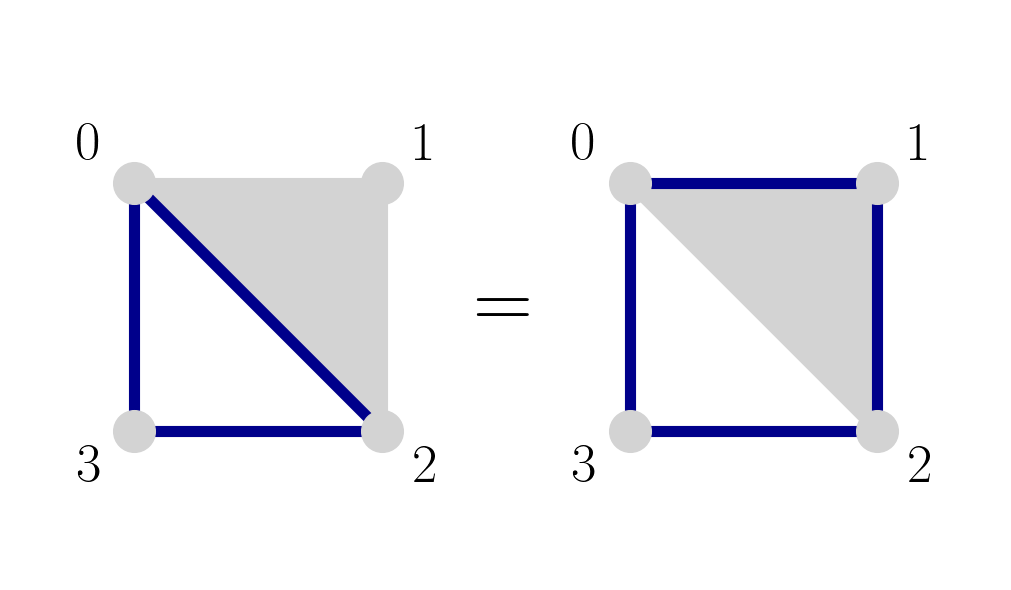

In [13]:
def plot_operador_ciclos():
    # Proporção horizontal ideal para manter os dois lados simétricos
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Parâmetros Estéticos Solicitados
    cor_face = "lightgray" # Cor azul padrão solicitada
    cor_borda_grau = 'lightgray'             # Cor cinza para elementos estruturais
    tamanho_fonte = 40                  
    grosso_linha = 8                   
    grosso_vertice = 30                
    
    # Coordenadas base do quadrado (lados de tamanho 1.0 unitário)
    v_base = np.array([
        [-0.5, 0.5],   # Vértice 0 (Superior Esquerdo)
        [0.5, 0.5],    # Vértice 1 (Superior Direito)
        [0.5, -0.5],   # Vértice 2 (Inferior Direito)
        [-0.5, -0.5]   # Vértice 3 (Inferior Esquerdo)
    ])
    
    arestas = [(0, 1), (1, 2), (2, 3), (3, 0), (0, 2)]
    labels = ['0', '1', '2', '3']
    
    # Offsets proporcionais para afastar a fonte grande tam 40 do centro do vértice
    offsets = [[-0.18, 0.15], [0.18, 0.15], [0.18, -0.15], [-0.18, -0.15]]

    # ==========================================================
    # DESENHO 1: Quadrado da ESQUERDA (Deslocamento Simétrico -1.0)
    # ==========================================================
    v1 = v_base - [1.0, 0]
    pts_tri1 = [v1[0], v1[1], v1[2]]
    
    # 1.1 Preencher triângulo diagonal superior (2-símplice ativo)
    t1 = patches.Polygon(pts_tri1, closed=True, facecolor=cor_face, edgecolor='none', zorder=1)
    ax.add_patch(t1)
    
    # 1.2 Desenhar arestas (Esquerda: todas as linhas continuam cinzas)
    for edge in arestas:
        if edge in [(0,2), (3,0), (2,3)]:
            ax.plot([v1[edge[0], 0], v1[edge[1], 0]], [v1[edge[0], 1], v1[edge[1], 1]], 
                color="darkblue", linewidth=grosso_linha, zorder=2)
        else:
            ax.plot([v1[edge[0], 0], v1[edge[1], 0]], [v1[edge[0], 1], v1[edge[1], 1]], 
                color=cor_borda_grau, linewidth=grosso_linha, zorder=2)
        
    # 1.3 Desenhar vértices (Esquerda: todos os vértices continuam cinzas)
    ax.plot(v1[:, 0], v1[:, 1], 'o', markersize=grosso_vertice, 
            markerfacecolor=cor_borda_grau, markeredgecolor="lightgray", zorder=3)
    
    # 1.4 Enumerar vértices
    for i in range(4):
        ax.text(v1[i, 0] + offsets[i][0], v1[i, 1] + offsets[i][1], labels[i], 
                fontsize=tamanho_fonte, fontweight='bold', ha='center', va='center')

    # ==========================================================
    # DESENHO 2: Símbolo de Igual (=) e Expressão Matemática
    # ==========================================================
    # Sinal de igual perfeitamente no ponto central neutro (0,0)
    ax.text(0, 0, "=", fontsize=60, fontweight='bold', ha='center', va='center', zorder=1)
    

    # ==========================================================
    # DESENHO 3: Quadrado da DIREITA (Deslocamento Simétrico +1.0)
    # ==========================================================
    v2 = v_base + [1.0, 0]
    pts_tri2 = [v2[0], v2[1], v2[2]]
    
    # 3.1 Preencher triângulo diagonal superior (Opcional: mantido limpo ou transparente)
    t2 = patches.Polygon(pts_tri2, closed=True, facecolor=cor_face, edgecolor='none', zorder=1)
    ax.add_patch(t2)
    
    # 3.2 Desenhar arestas filtradas (Destaque para o contorno do triângulo: 0-1, 1-2, 0-2)
    for edge in arestas:
        if edge == (0, 2):
            ax.plot([v2[edge[0], 0], v2[edge[1], 0]], [v2[edge[0], 1], v2[edge[1], 1]], 
                    color=cor_borda_grau, linewidth=grosso_linha, zorder=2)
        else:
            ax.plot([v2[edge[0], 0], v2[edge[1], 0]], [v2[edge[0], 1], v2[edge[1], 1]], 
                    color="darkblue", linewidth=grosso_linha, zorder=2)
            
    ax.plot(v2[:, 0], v2[:, 1], 'o', markersize=grosso_vertice, 
            markerfacecolor=cor_borda_grau, markeredgecolor="lightgray", zorder=3)
    
    # 3.4 Enumerar vértices
    for i in range(4):
        ax.text(v2[i, 0] + offsets[i][0], v2[i, 1] + offsets[i][1], labels[i], 
                fontsize=tamanho_fonte, fontweight='bold', ha='center', va='center')

    # ==========================================================
    # Padronização de Limites, Proporção e Remoção de Bordas
    # ==========================================================
    # Estreitamos os limites para aproximar e focar nos elementos
    ax.set_xlim(-2.0, 2.0)
    ax.set_ylim(-1.1, 1.2)
    
    ax.set_aspect('equal') # Impede distorções no formato quadrado das formas
    ax.axis('off')         # Remove os eixos cartesianos numéricos do plano
    
    plt.tight_layout()
    plt.show()

# Executa o gráfico do Operador Fronteira
plot_operador_ciclos()

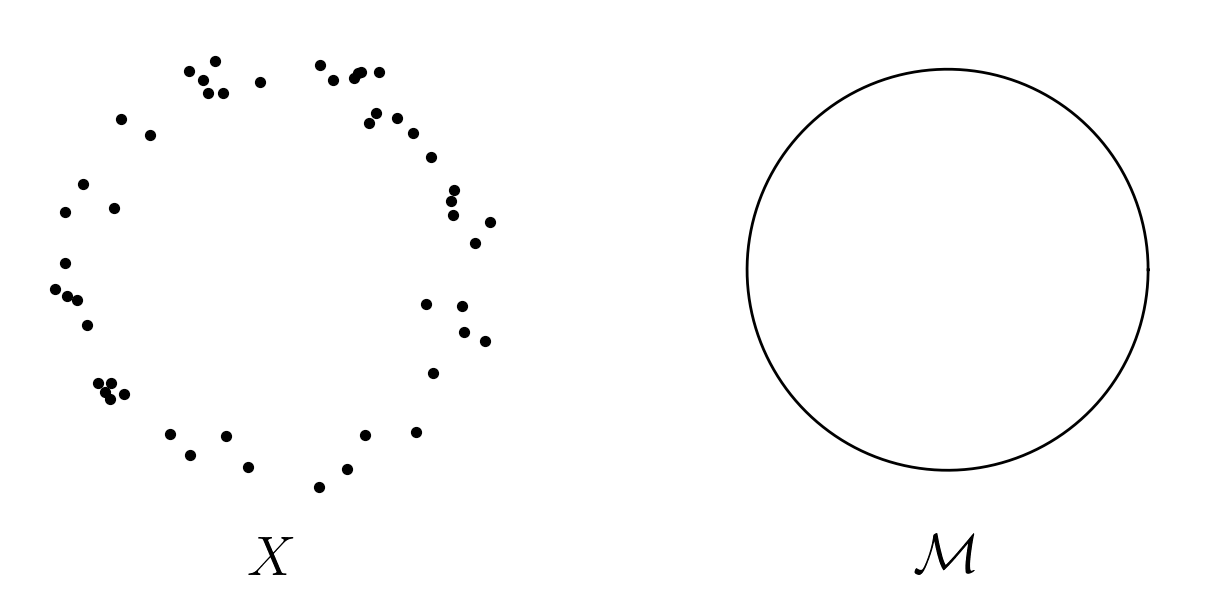

In [14]:
def plot_nuvem_e_circulo_perfeito():
    # Cria um painel com 1 linha e 2 colunas
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Configuração comum de semente para reproducibilidade
    np.random.seed(42)
    
    # ==========================================================
    # IMAGEM 1: Nuvem de 50 pontos aleatórios (Amostra com Ruído)
    # ==========================================================
    num_pontos = 50
    raio_medio = 1.0
    
    # Ângulos aleatórios entre 0 e 2*pi
    angulos = np.random.uniform(0, 2 * np.pi, num_pontos)
    # Raio com ruído gaussiano pequeno (desvio padrão de 0.08)
    ruido = np.random.normal(0, 0.08, num_pontos)
    raios_com_ruido = raio_medio + ruido
    
    # Conversão de coordenadas polares para cartesianas (X, Y)
    x_nuvem = raios_com_ruido * np.cos(angulos)
    y_nuvem = raios_com_ruido * np.sin(angulos)
    
    # Plota a nuvem de pontos (0-símplices)
    axes[0].scatter(x_nuvem, y_nuvem, color='black', s=50, zorder=2)
    
    # ==========================================================
    # IMAGEM 2: Contorno de um Círculo Perfeito (Espaço Topológico S¹)
    # ==========================================================
    # Gera 500 pontos densos e sequenciais para criar uma linha contínua e suave
    angulos_perfeitos = np.linspace(0, 2 * np.pi, 500)
    x_perfeito = raio_medio * np.cos(angulos_perfeitos)
    y_perfeito = raio_medio * np.sin(angulos_perfeitos)
    
    # Plota o contorno contínuo do círculo
    axes[1].plot(x_perfeito, y_perfeito, color='black', linewidth=2, zorder=2)
    
    # ==========================================================
    # Padronização de Limites, Proporção e Remoção de Bordas
    # ==========================================================

    titulos = [r"$X$", r"$\mathcal{M}$"]
    for i, ax in enumerate(axes):
        # Define limites ligeiramente maiores que o raio 1.0 para não cortar as bordas
        ax.set_xlim(-1.3, 1.3)
        ax.set_ylim(-1.3, 1.3)
        ax.set_aspect('equal') # Garante proporção 1:1 (evita que o círculo pareça uma elipse)
        ax.set_title(titulos[i], y=-0.1, fontsize=40, fontweight='bold')
        ax.axis('off')         # Oculta os eixos cartesianos numéricos
        
    plt.tight_layout()
    plt.show()

# Executa a geração das duas imagens lado a lado
plot_nuvem_e_circulo_perfeito()

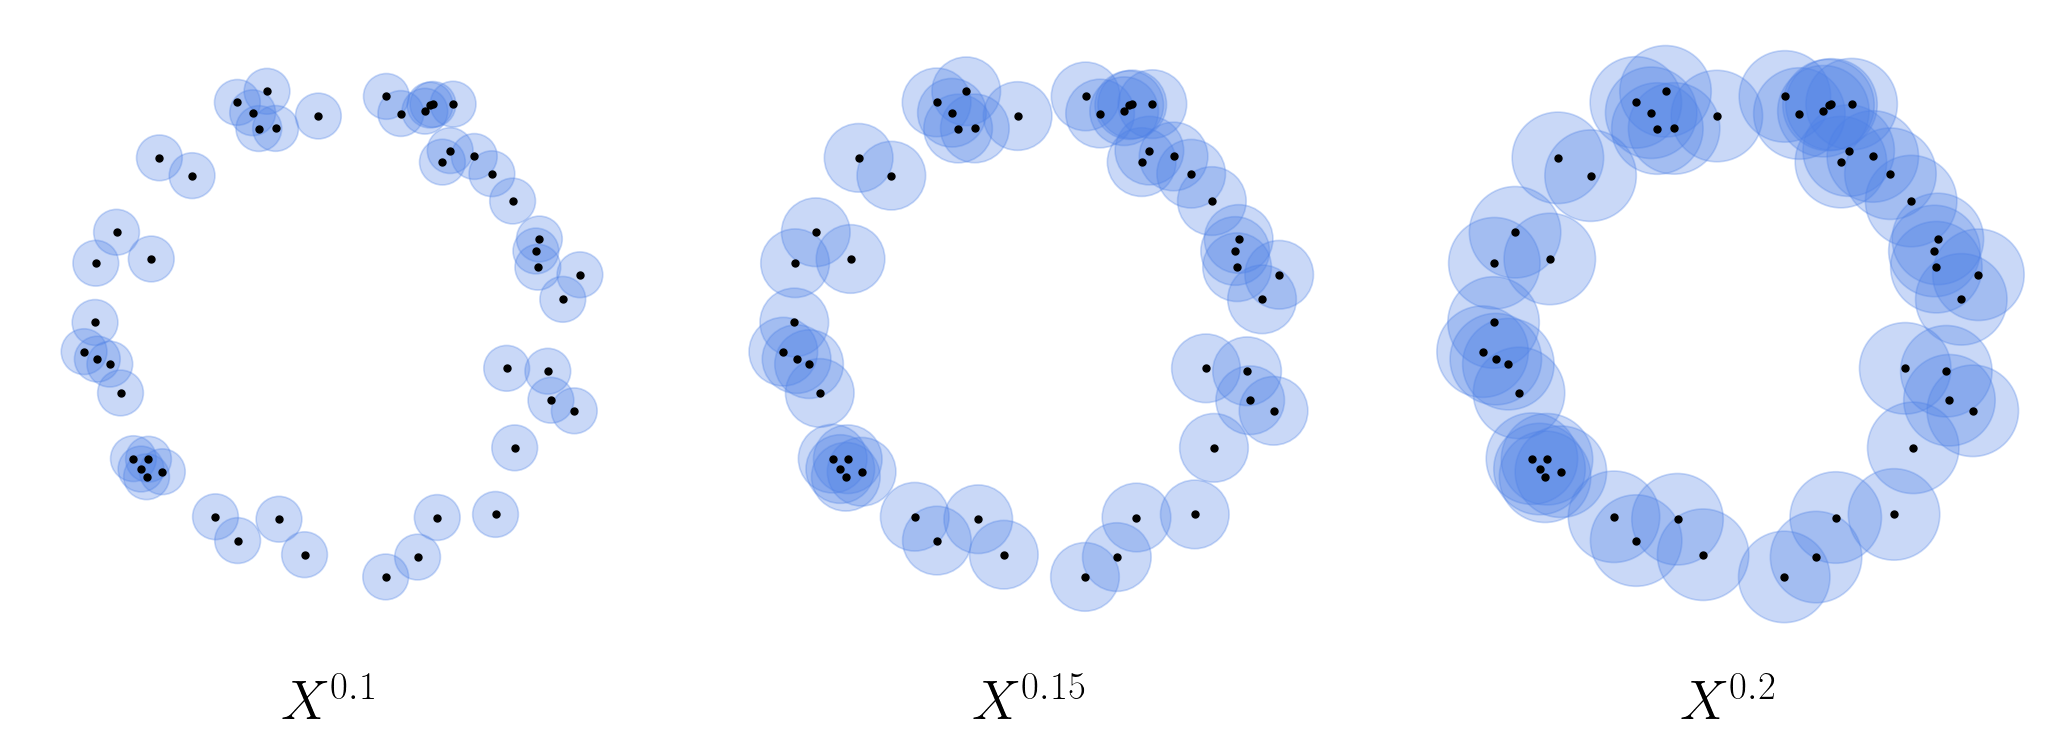

In [15]:
def plot_crescimento_esferas_tda():
    # Cria uma grade com 1 linha e 3 colunas para os raios solicitados
    fig, axes = plt.subplots(1, 3, figsize=(21, 7))
    
    # 1. Recriação exata da mesma nuvem de 50 pontos circular com ruído
    np.random.seed(42)
    num_pontos = 50
    raio_medio = 1.0
    angulos = np.random.uniform(0, 2 * np.pi, num_pontos)
    ruido = np.random.normal(0, 0.08, num_pontos)
    raios_com_ruido = raio_medio + ruido
    
    x_nuvem = raios_com_ruido * np.cos(angulos)
    y_nuvem = raios_com_ruido * np.sin(angulos)
    
    # Lista com as configurações dos raios das bolas
    raios_bolas = [0.1, 0.15, 0.2]
    titulos = [r"$X^{0.1}$", r"$X^{0.15}$", r"$X^{0.2}$"]
    cor = (0.3, 0.5, 0.9, 0.3)
    # Loop para construir cada uma das 3 fases de crescimento das esferas
    for i in range(3):
        ax = axes[i]
        raio_atual = raios_bolas[i]
        
        # A) Desenhar as bolas (esferas translúcidas) centradas em cada ponto
        for px, py in zip(x_nuvem, y_nuvem):
            # Usando uma cor leve de preenchimento (cinza) com contorno sutil
            bola = plt.Circle((px, py), raio_atual, 
                              facecolor=cor, 
                              edgecolor=cor, 
                              linewidth=1.2, zorder=1)
            ax.add_patch(bola)
            
        # B) Desenhar os pontos centrais (0-símplices) por cima das esferas
        ax.scatter(x_nuvem, y_nuvem, color='black', s=25, zorder=2)
        
        # C) Configurações de exibição e títulos posicionados embaixo
        ax.set_xlim(-1.4, 1.4)
        ax.set_ylim(-1.4, 1.4)
        ax.set_aspect('equal') # Mantém a proporção 1:1 sem achatar o círculo
        ax.axis('off')         # Remove as bordas padrão do gráfico do matplotlib
        ax.set_title(titulos[i], y=-0.12, fontsize=40, fontweight='bold')
        
    plt.tight_layout(w_pad=2.0)
    plt.show()

# Executa o plot das 3 imagens de filtração
plot_crescimento_esferas_tda()

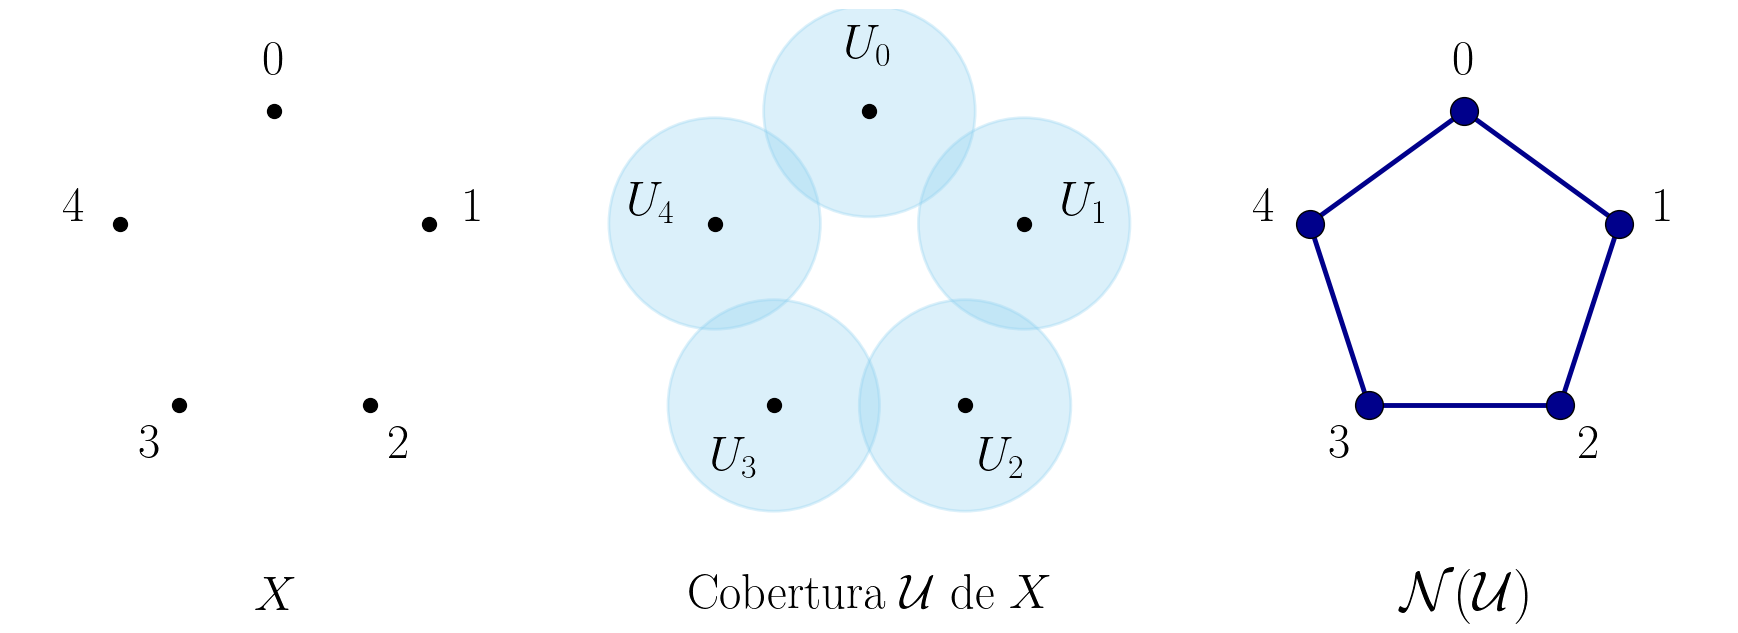

In [16]:
def plot_nuvem_cobertura_nervo():
    # Cria uma grade horizontal com 1 linha e 3 colunas
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # 1. Coordenadas de 5 pontos distribuídos em um círculo de raio 0.8
    angulos = np.linspace(0, 2 * np.pi, 5, endpoint=False)
    v = np.column_stack((0.8 * np.sin(angulos), 0.8 * np.cos(angulos)))
    
    labels = ['0', '1', '2', '3', '4']
    
    # Parâmetros estéticos (Mantendo o padrão azul translúcido e darkblue do seu trabalho)
    cor_bola = (0.54, 0.81, 0.94, 0.3)
    cor_borda_bola = (0.54, 0.81, 0.94, 0.3)
    cor_nervo = 'darkblue'
    
    # Raio crítico calculado: as arestas vizinhas medem 0.94, então r=0.52 garante 
    # que vizinhos se intersectam (2r = 1.04 > 0.94), mas não vizinhos não se tocam.
    raio = 0.52 
    
    # -------------------------------------------------------------------------
    # COLUNA 1: Nuvem de Pontos (Espaço Topológico Discreto X)
    # -------------------------------------------------------------------------
    axes[0].plot(v[:, 0], v[:, 1], 'ko', markersize=10, zorder=2)
    # Rótulos numéricos dos pontos
    for i in range(5):
        axes[0].text(v[i, 0] * 1.3, v[i, 1] * 1.3, labels[i], 
                     fontsize=35, fontweight='bold', ha='center', va='center')
    axes[0].set_title("$X$", y=-0.15, fontsize=35, fontweight='bold')
    
    # -------------------------------------------------------------------------
    # COLUNA 2: Cobertura de X (Coleção de abertos U_i satisfazendo seu LaTeX)
    # -------------------------------------------------------------------------
    axes[1].plot(v[:, 0], v[:, 1], 'ko', markersize=10, zorder=3)
    for i in range(5):
        # Cria e adiciona cada bola aberta U_i centralizada no ponto
        bola = patches.Circle((v[i, 0], v[i, 1]), raio, facecolor=cor_bola, 
                              edgecolor=cor_borda_bola, linewidth=2, zorder=1)
        axes[1].add_patch(bola)
        # Identificação de cada subconjunto aberto U_i
        axes[1].text(v[i, 0] * 1.4, v[i, 1] * 1.4, f"$U_{labels[i]}$", 
                     fontsize=35, fontweight='bold', ha='center', va='center', zorder=4)
    axes[1].set_title(r"Cobertura $\mathcal{U}$ de $X$", y=-0.15, fontsize=35, fontweight='bold')
    
    # -------------------------------------------------------------------------
    # COLUNA 3: O Nervo de X (Complexo Simplicial N(U))
    # -------------------------------------------------------------------------
    # Desenha os 0-símplices (vértices do Nervo mapeados nos centros)
    axes[2].plot(v[:, 0], v[:, 1], 'ko', markersize=20, zorder=3, 
                 markerfacecolor=cor_nervo, markeredgecolor='black')
    
    # Aplicação algorítmica da sua Definição: Se U_i ∩ U_j != vazio, adicione 1-símplice
    # Geometricamente, se a distância entre centros for <= 2 * raio, as bolas se intersectam.
    for i in range(5):
        for j in range(i + 1, 5):
            distancia = np.linalg.norm(v[i] - v[j])
            if distancia <= 2 * raio:
                axes[2].plot([v[i, 0], v[j, 0]], [v[i, 1], v[j, 1]], 
                             color=cor_nervo, linewidth=3.5, zorder=2)
                
    for i in range(5):
        axes[2].text(v[i, 0] * 1.3, v[i, 1] * 1.3, labels[i], 
                     fontsize=35, fontweight='bold', ha='center', va='center')
        
    axes[2].set_title(r"$\mathcal{N}(\mathcal{U})$", y=-0.15, fontsize=40, fontweight='bold')
    
    # -------------------------------------------------------------------------
    # Padronização de Layout de todos os Subplots
    # -------------------------------------------------------------------------
    for ax in axes:
        ax.set_xlim(-1.3, 1.3)
        ax.set_ylim(-1.3, 1.3)
        ax.set_aspect('equal') # Mantém a proporção circular perfeita
        ax.axis('off')         # Oculta grades e eixos numéricos cartesianos
        
    plt.tight_layout()
    plt.show()

# Executa a função didática
plot_nuvem_cobertura_nervo()

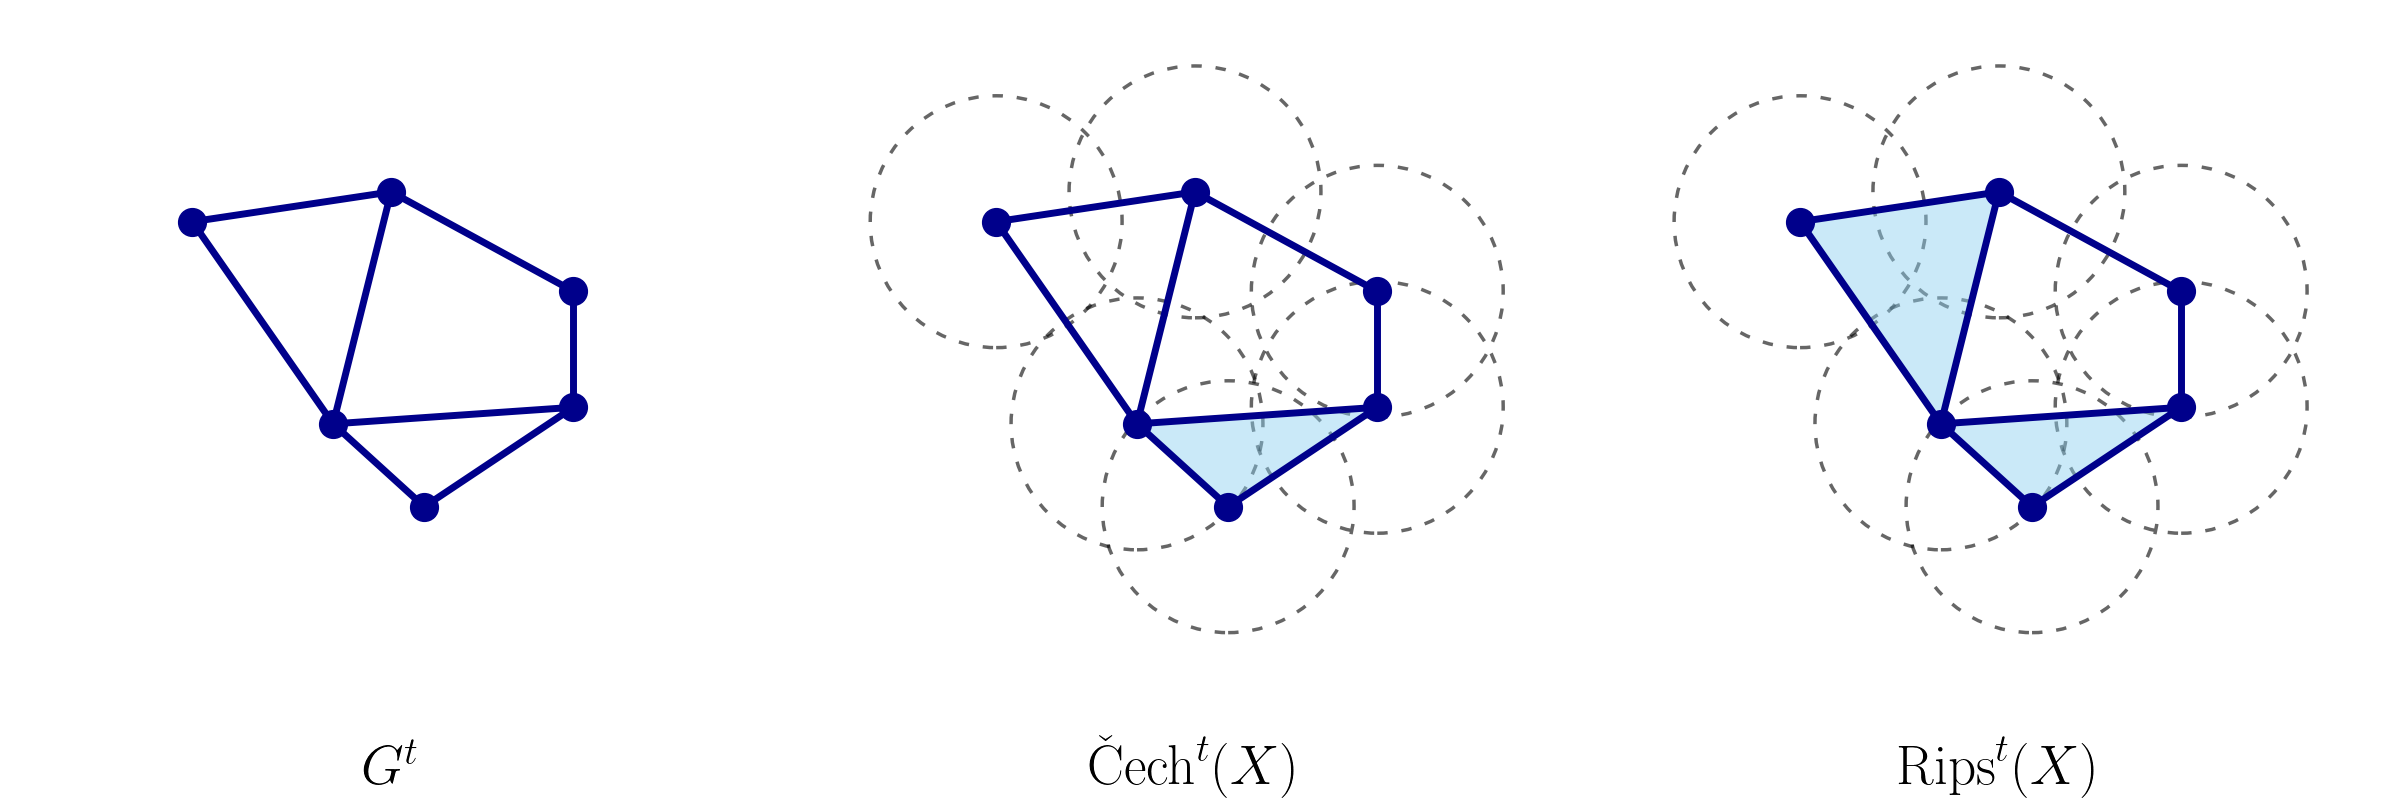

In [17]:
def plot_cech_vs_rips():
    fig, axes = plt.subplots(1, 3, figsize=(24, 8))
    
    # Paleta de Cores e Estilos Solicitados
    cor_azul_preenchimento = (0.54, 0.81, 0.94, 0.45)
    cor_azul_solida = 'darkblue'
    
    grosso_linha = 5
    grosso_vertice = 20
    tamanho_titulo = 40
    
    # 1. Matriz preservando os seus 6 pontos exatos informados
    v = np.array([
        [-0.35, 0.0],    # Ponto 0 -> índice 0 no código
        [0.2, -0.5],   # Ponto 3 -> índice 1 no código
        [-1.2, 1.22],    # Ponto 4 -> índice 2 no código
        [1.1, 0.8],     # Ponto 6 -> índice 3 no código
        [1.1, 0.1],     # Ponto 7 -> índice 4 no código
        [0.0, 1.4]      # Ponto 8 -> índice 5 no código
    ])
    
    # Mapeamento das arestas para os dois triângulos distintos solicitados:
    # Triângulo Superior formado por 8, 4 e 0  -> índices (5, 2, 0)
    # Triângulo Inferior formado por 0, 3 e 7   -> índices (0, 1, 4)
    arestas = [
        (5, 2), (2, 0), (5, 0),  # Triângulo Superior (8, 4, 0)
        (0, 1), (1, 4), (0, 4),   # Triângulo Inferior (0, 3, 7)
        (3,4),
        (3,5)
    ]
    
    triangulo_superior = [v[5], v[2], v[0]]
    triangulo_inferior  = [v[0], v[1], v[4]]
    

    raio_bola = 0.76

    # -------------------------------------------------------------------------
    # IMAGEM 1: O Grafo G^t (Dois triângulos nítidos e vazios)
    # -------------------------------------------------------------------------
    for edge in arestas:
        axes[0].plot([v[edge[0], 0], v[edge[1], 0]], [v[edge[0], 1], v[edge[1], 1]], 
                     color=cor_azul_solida, linewidth=grosso_linha, zorder=2)
        
    axes[0].plot(v[:, 0], v[:, 1], 'o', markersize=grosso_vertice, 
                 markerfacecolor=cor_azul_solida, markeredgecolor=cor_azul_solida, zorder=3)
    
    axes[0].set_title(r"$G^t$", y=-0.05, fontsize=tamanho_titulo, fontweight='bold')

    # -------------------------------------------------------------------------
    # IMAGEM 2: O Complexo de Čech^t(X) (Apenas o triângulo superior preenchido)
    # -------------------------------------------------------------------------
    # Contorno pontilhado largo para as 6 esferas abertas
    for i in range(6):
        bola = patches.Circle((v[i, 0], v[i, 1]), raio_bola, fill=False, 
                              edgecolor='black', linestyle=(0, (3, 4)), linewidth=2.5, alpha=0.6, zorder=1)
        axes[1].add_patch(bola)
        
    # Preenchimento do 2-símplice superior (onde há interseção tripla comum no centro)
    t_cech = patches.Polygon(triangulo_inferior, closed=True, facecolor=cor_azul_preenchimento, edgecolor='none', zorder=2)
    axes[1].add_patch(t_cech)
    
    for edge in arestas:
        axes[1].plot([v[edge[0], 0], v[edge[1], 0]], [v[edge[0], 1], v[edge[1], 1]], 
                     color=cor_azul_solida, linewidth=grosso_linha, zorder=3)
        
    axes[1].plot(v[:, 0], v[:, 1], 'o', markersize=grosso_vertice, 
                 markerfacecolor=cor_azul_solida, markeredgecolor=cor_azul_solida, zorder=4)
    
    axes[1].set_title(r"$\check{\mathrm{C}}\mathrm{ech}^t(X)$", y=-0.05, fontsize=tamanho_titulo, fontweight='bold')

    # -------------------------------------------------------------------------
    # IMAGEM 3: O Complexo de Rips^t(X) (Ambos os triângulos preenchidos)
    # -------------------------------------------------------------------------
    # Contorno pontilhado largo para as 6 esferas abertas
    for i in range(6):
        bola = patches.Circle((v[i, 0], v[i, 1]), raio_bola, fill=False, 
                              edgecolor='black', linestyle=(0, (3, 4)), linewidth=2.5, alpha=0.6, zorder=1)
        axes[2].add_patch(bola)
        
    # Preenche ambos os triângulos (Rips preenche pois todas as arestas par a par existem)
    t_rips1 = patches.Polygon(triangulo_superior, closed=True, facecolor=cor_azul_preenchimento, edgecolor='none', zorder=2)
    t_rips2 = patches.Polygon(triangulo_inferior, closed=True, facecolor=cor_azul_preenchimento, edgecolor='none', zorder=2)
    axes[2].add_patch(t_rips1)
    axes[2].add_patch(t_rips2)
    
    for edge in arestas:
        axes[2].plot([v[edge[0], 0], v[edge[1], 0]], [v[edge[0], 1], v[edge[1], 1]], 
                     color=cor_azul_solida, linewidth=grosso_linha, zorder=3)
        
    axes[2].plot(v[:, 0], v[:, 1], 'o', markersize=grosso_vertice, 
                 markerfacecolor=cor_azul_solida, markeredgecolor=cor_azul_solida, zorder=4)
    
    axes[2].set_title(r"$\mathrm{Rips}^t(X)$", y=-0.05, fontsize=tamanho_titulo, fontweight='bold')

    # -------------------------------------------------------------------------
    # Padronização de Limites, Proporção e Ocultação dos Eixos Cartesianos
    # -------------------------------------------------------------------------
    for ax in axes:
        ax.set_xlim(-2.3, 2.3)
        ax.set_ylim(-2.0, 2.5)
        ax.set_aspect('equal')
        ax.axis('off')
        
    plt.tight_layout(w_pad=3.0)
    plt.show()

# Executa o plot das subcamadas simpliciais
plot_cech_vs_rips()

In [2]:
protein = pr.parseMMCIF(r"Dados\dataset\apo\1omp.cif.gz")
        
calphas = protein.select("calpha and chain A")
coordenadas = calphas.getCoords()

In [ ]:
fonte_latex = dict(
    family="Cambria, 'Times New Roman', 'Computer Modern', serif",
    size=40,
    color="black"
)

fig_global = None
simplices_global = []
X_g, Y_g, Z_g = None, None, None
filtracoes_global = []

def plot_rips_3d(coordenadas, d_max=12.0):
    global fig_global, slider_global, simplices_global, X_g, Y_g, Z_g, filtracoes_global
 
    # .tolist() é o ponto-chave: nunca passar ndarray cru para as traces
    # de um FigureWidget, só listas Python.
    X_g = coordenadas[:, 0].tolist()
    Y_g = coordenadas[:, 1].tolist()
    Z_g = coordenadas[:, 2].tolist()
 
    rips = gudhi.RipsComplex(points=coordenadas, max_edge_length=d_max)
    st = rips.create_simplex_tree(max_dimension=3)
    simplices_global = sorted(st.get_simplices(), key=lambda sf: sf[1])
    filtracoes_global = [f for _, f in simplices_global]
 
    fig_global = go.FigureWidget()
    fig_global.add_trace(go.Scatter3d(x=X_g, y=Y_g, z=Z_g, mode='markers',
                                       marker=dict(size=4, color='black'), name='0-Símplices'))
    fig_global.add_trace(go.Scatter3d(x=[], y=[], z=[], mode='lines',
                                       line=dict(color='gray', width=2), name='1-Símplices'))
    fig_global.add_trace(go.Mesh3d(x=X_g, y=Y_g, z=Z_g, i=[], j=[], k=[],
                                    color='rgba(255, 255, 0, 0.2)', name='2-Símplices'))
    fig_global.add_trace(go.Mesh3d(x=X_g, y=Y_g, z=Z_g, i=[], j=[], k=[],
                                    color='rgba(144, 238, 144, 0.3)', name='3-Símplices'))
 
    fig_global.update_layout(
        scene=dict(xaxis_visible=False, yaxis_visible=False, zaxis_visible=False, bgcolor='rgba(0,0,0,0)'),
        showlegend=False,
        title=dict(text="d = 0.0 Å", y=0.05, x=0.5,
                   xanchor='center', yanchor='bottom', font=fonte_latex),
        margin=dict(l=0, r=0, b=40, t=10),
        height=600
    )
 
    slider_global = widgets.FloatSlider(
        value=0.0, min=0.0, max=d_max, step=0.1,
        description='Distância (Å):',
        continuous_update=False,
        layout=widgets.Layout(width='80%')
    )
 
    def atualizar_grafico(change):
        d = change.new
        idx = bisect.bisect_right(filtracoes_global, d)

        edges_x, edges_y, edges_z = [], [], []
        tri_i, tri_j, tri_k = [], [], []
        tet_i, tet_j, tet_k = [], [], []

        for simplex, _ in simplices_global[:idx]:
            dim = len(simplex) - 1
            if dim == 1:
                a, b = simplex
                edges_x.extend([X_g[a], X_g[b], None])
                edges_y.extend([Y_g[a], Y_g[b], None])
                edges_z.extend([Z_g[a], Z_g[b], None])
            elif dim == 2:
                tri_i.append(simplex[0]); tri_j.append(simplex[1]); tri_k.append(simplex[2])
            elif dim == 3:
                a, b, c, e = simplex
                tet_i.extend([a, a, a, b])
                tet_j.extend([b, b, c, c])
                tet_k.extend([c, e, e, e])
        print("Testando")
        print(len(tri_i), len(tet_i))
        with fig_global.batch_update():
            if d >= 4.0:
                fig_global.data[0].x, fig_global.data[0].y, fig_global.data[0].z = [], [], []
            else:
                fig_global.data[0].x, fig_global.data[0].y, fig_global.data[0].z = X_g, Y_g, Z_g
            fig_global.data[1].x, fig_global.data[1].y, fig_global.data[1].z = edges_x, edges_y, edges_z
            fig_global.data[2].i, fig_global.data[2].j, fig_global.data[2].k = tri_i, tri_j, tri_k
            fig_global.data[3].i, fig_global.data[3].j, fig_global.data[3].k = tet_i, tet_j, tet_k
            fig_global.layout.title.text = f"d = {d:.1f} Å"
 
    slider_global.observe(atualizar_grafico, names='value')
    display(widgets.VBox([slider_global, fig_global]))
 
 
def salvar_png(nome_base="rips_protein", scale=4, width=1000, height=1000):
    if fig_global is None or slider_global is None:
        print("Rode plot_rips_3d primeiro.")
        return
    nome = f"{nome_base}.png".replace(' ', '_').replace('Å', '')
    fig_estatica = go.Figure(fig_global)
    for trace in fig_estatica.data:
        if trace.type == 'mesh3d':
            trace.opacity = 1.0  # kaleido não exporta alpha de Mesh3d de forma confiável
    fig_estatica.write_image(nome, scale=scale, width=width, height=height)
    print(f"Salvo: {nome}")
 
 
campo_nome = widgets.Text(value='rips_protein', description='Nome:')
botao_salvar = widgets.Button(description='Salvar PNG', button_style='success')
saida_salvar = widgets.Output()
 
 
def _on_click_salvar(b):
    with saida_salvar:
        saida_salvar.clear_output()
        salvar_png(nome_base=campo_nome.value)
 
 
botao_salvar.on_click(_on_click_salvar)
# 1. Executa o plot interativo
plot_rips_3d(coordenadas[:100])
 
# 2. Exibe o controle de salvamento (usa o d atual do slider acima)
display(widgets.HBox([campo_nome, botao_salvar]), saida_salvar)

Output()

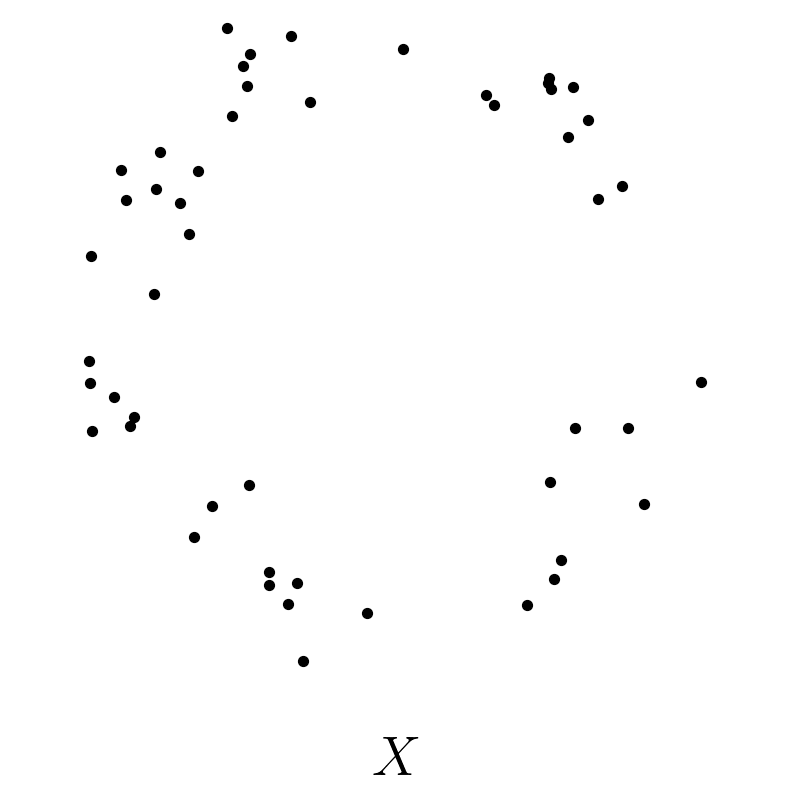

In [27]:
def SampleOnCircle(N = 100, sd = 0):

    '''

    Sample N_observation points from the uniform distribution on the unit circle

    in R^2, with Gaussian noise of standard deviation sd.

       

    Input:

        N (int): number of sample points on the circle.

        N_noise (float, optional): standard deviation of the Gaussian noise

   

    Output :

        data (np.array): size Nx2, the points concatenated.

    '''

    rand_uniform = np.random.rand(N)*2-1    

    X = np.cos(2*np.pi*rand_uniform)

    Y = np.sin(2*np.pi*rand_uniform)

    data = np.stack((X,Y)).transpose() + np.random.normal(0, sd,  (N, 2))

    return data


def BettiNumbers(st, verbose = 'True'):

    '''

    Print the Betti numbers of the simplicial complex 'st'.

   

    Input:

        st: a gudhi.SimplexTree

       

    Example:

        st = gudhi.SimplexTree()

        st.insert([0])

        st.insert([1])

        BettiNumbers(st)

    '''    

    if st.dimension()==0:

        betti_numbers = [st.num_simplices()]

    else:

        st.compute_persistence()

        betti_numbers = st.betti_numbers()

    if verbose:

        print('The Betti numbers are:')

        for i in range(len(betti_numbers)):

            print('Beta_'+repr(i)+' = '+repr(betti_numbers[i]))

    return betti_numbers


def PlotThickening(X,t):

    '''

    Plot a matplotlib figure representing the t-thickening of the point cloud X.

    X must be a point cloud in the plane.

   

    Input:

        X (np.array): size Nx2, the points concatenated.

       

    Example:

        X = np.asarray([[0,1],[1,0],[-1,1]])

        PlotThickening(X, 0.2)

    '''

    if np.shape(X)[1]!=2:

        print('Error! X is not in R^2')

        return False

    N=np.shape(X)[0]

    fig = plt.figure(figsize=(8,8)); ax = fig.add_subplot()

    for i in range(N):

        circle = plt.Circle((X[i,0], X[i,1]), t, color='magenta', alpha = 0.3)

        ax.add_artist(circle)

    for i in range(N):

        point = plt.Circle((X[i,0], X[i,1]), 0.02, facecolor='black', edgecolor = 'black', alpha = 1)

        ax.add_artist(point)

    bound = np.max(np.abs(X))+t    

    plt.xlim(-bound, bound); plt.ylim(-bound, bound)

    plt.axis('off')

    plt.show()


def GetBettiCurvesFromPointCloud(X, J, dim=3):

    '''

    Computes the Betti curves of the Rips complex on the point cloud X,

    on the interval J, up to dimension dim.



    Input:

        X (np.array): size Nx2, the point cloud.

        J (np.array): interval. Shape 1xM.

        dim (int, optional): maximal dimension to compute the Betti curves.

   

    Output:

        BettiCurves (np.array): the Betti curves. Shape (dim+1)xM. The ith

                                Betti curve is given by BettiCurve[i,:].  

                               

    Example:

        X = np.asarray([[0,1],[1,0],[-1,1]])

        J = np.linspace(0,1,100)

        GetBettiCurvesFromPointCloud(X, J, dim = 2)

    '''

    I = 2*J

    tmax = max(I)

    rips = gudhi.RipsComplex(points=X, max_edge_length = tmax)

    st = rips.create_simplex_tree(max_dimension=dim)

    st.persistence(persistence_dim_max=True, homology_coeff_field = 2)

    Diagrams = [st.persistence_intervals_in_dimension(i) for i in range(dim+1)]

    BettiCurves = []

    step_x = I[1]-I[0]

    for diagram in Diagrams:

        bc =  np.zeros(len(I))

        if diagram.size != 0:

            diagram_int = np.clip(np.ceil((diagram[:,:2] - I[0]) / step_x), 0, len(I)).astype(int)

            for interval in diagram_int:

                bc[interval[0]:interval[1]] += 1

        BettiCurves.append(np.reshape(bc,[1,-1]))

    return np.reshape(BettiCurves, (dim+1, len(I)))


def GetBettiCurvesFromDistances(D, J, dim=2):

    '''

    Computes the Betti curves of the Rips complex of the distance matrix D,

    on the interval J, up to dimension dim.



    Input:

        D (np.array): size NxN, the distance matrix.

        J (np.array): interval. Shape 1xM.

        dim (int, optional): maximal dimension to compute the Betti curves.

   

    Output:

        BettiCurves (np.array): the Betti curves. Shape (dim+1)xM. The ith

                                Betti curve is given by BettiCurve[i,:].  



    Example:

        D = np.asarray([[0,1,2],[1,0,3],[2,3,0]])

        J = np.linspace(0,1,100)

        GetBettiCurvesFromDistances(D, J, dim = 1)

    '''

    I = 2*J

    tmax = max(I)

    rips = gudhi.RipsComplex(distance_matrix = D, max_edge_length = tmax)

    st = rips.create_simplex_tree(max_dimension=dim)

    st.persistence(persistence_dim_max=True, homology_coeff_field = 2)

    Diagrams = [st.persistence_intervals_in_dimension(i) for i in range(dim+1)]

    BettiCurves = []

    step_x = I[1]-I[0]

    for diagram in Diagrams:

        bc =  np.zeros(len(I))

        if diagram.size != 0:

            diagram_int = np.clip(np.ceil((diagram[:,:2] - I[0]) / step_x), 0, len(I)).astype(int)

            for interval in diagram_int:

                bc[interval[0]:interval[1]] += 1

        BettiCurves.append(np.reshape(bc,[1,-1]))

    return np.reshape(BettiCurves, (dim+1, len(I)))


def plot_diagram(st, ax, title):

    persistence = st.persistence(homology_coeff_field=2)

    gudhi.plot_persistence_diagram(persistence, axes=ax)

    ax.set_title(title)


N = 50 # number of points
sd = 0.1 # standard deviation of the noise
t = 0.2
X = SampleOnCircle(N, sd)
# plotting the point cloud
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"]
})

# 1. Criando a figura e desenhando os pontos
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(1, 1, 1)
plt.scatter(X[:,0], X[:,1], c='black', s=50)
plt.axis('equal')
plt.axis('off')

# 2. Configurando o título para ficar EMBAIXO da imagem
# y=-0.1 empurra para baixo do eixo horizontal
# pad=-20 ajuda no ajuste fino para não cortar a letra
plt.title(r"$X$", y=-0.1, pad=-20, fontsize=40)

# 3. Ajustando margens e exibindo o gráfico (SEMPRE POR ÚLTIMO)
plt.tight_layout()
plt.show()

# --- Seu processamento com o GUDHI continua aqui embaixo ---
st = gudhi.SimplexTree()
for i in range(N):
    st.insert([i])
for i in range(N):
    for j in range(i):
        if np.linalg.norm(X[i,:]-X[j,:])<=2*t:
            st.insert([i,j])
st.expansion(2)


In [28]:
BettiNumbers(st)

The Betti numbers are:
Beta_0 = 3
Beta_1 = 0


[3, 0]

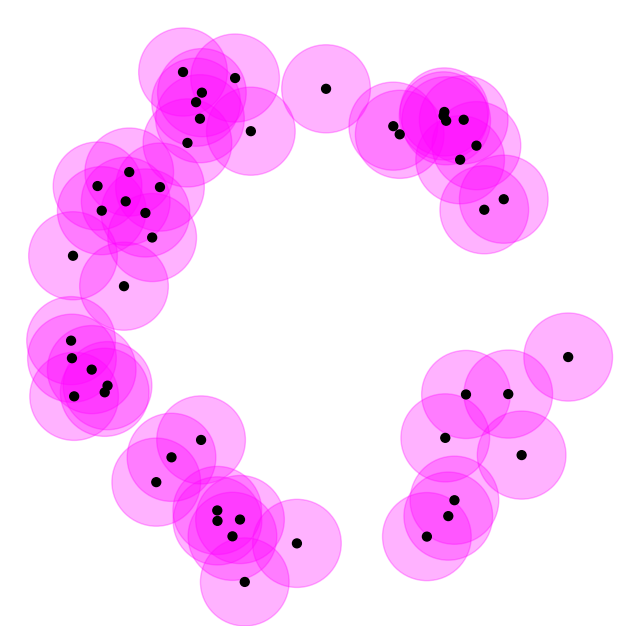

In [29]:
PlotThickening(X, 0.2)

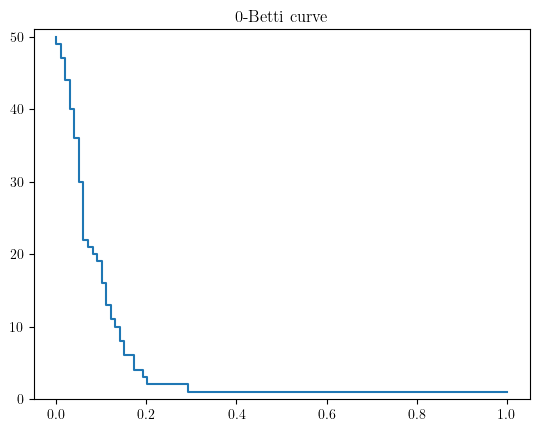

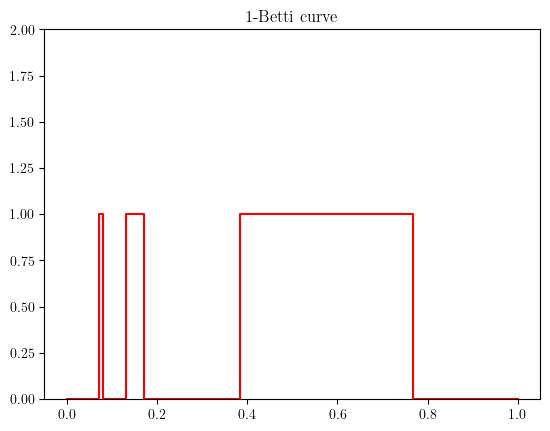

In [31]:
I = np.linspace(0,1,100)
Betti_curves = GetBettiCurvesFromPointCloud(X, I)
plt.figure()
plt.step(I, Betti_curves[0])
plt.ylim(0, max(Betti_curves[0])+1)
plt.title('0-Betti curve')
plt.show()
plt.figure()
plt.step(I, Betti_curves[1], color = "red")
plt.ylim(0, max(Betti_curves[1])+1)
plt.title('1-Betti curve')
plt.show()

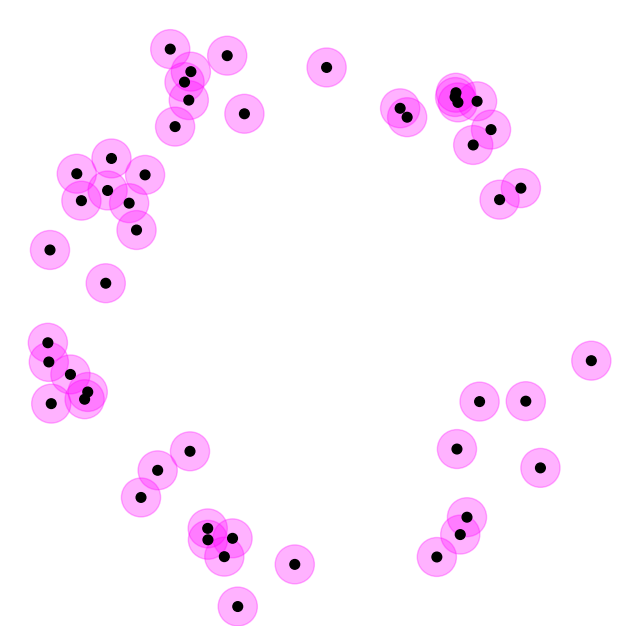

In [32]:
t_noise = I[np.where(Betti_curves[1]>0)][0]
# first appartition of topological noise
PlotThickening(X,t=t_noise)
